---
# **UCCD3133: Assignment 2**
---


## **Group Information**

**Group Number:** 34

> **Member 1:** *Lim Qing*
>
> **Member 2:** *Law Ying Yee*
>
> **Member 3:** *Chong Zhi Cong*




---

## **Work Distrubution**

* **Prompt Engineering:** *Lim Qing*

* **Ingestion:** *Lim Qing*

* **Vector Store:** *Lim Qing*

* **Memory & States :** *Lim Qing*

* **Query Compiler Chain :** *Law Ying Yee*

* **Query router chain :** *Law Ying Yee*

* **Analyzer Chain 1:** *Law Ying Yee*

* **Analyzer Chain 2:** *Law Ying Yee*

* **Run parallel retriever :** *Chong Zhi Cong*

* **Context compiler chain :** *Chong Zhi Cong*

* **Responder chain :** *Chong Zhi Cong*

* **Assistant class & Chat interface :** *Chong Zhi Cong*


---

## **Heading Structure of Source Documents**


**Document 1: CPSA+ Guidebook for
Registered Suppliers**

```
1. Preface
2. Logging into RS account
3. Creating new RS Account
4. Dashboard Overview
  	4.1. Controlled Goods Status (CoC)
  	4.2. Controlled Goods Status (SDoC)
  	4.3. Ongoing Allocated Certification Numbers (ACN)
  	4.4. Dashboard: Ongoing drafts
5. RS Profile Page Overview
6. Overview: “My Controlled Goods” Page
  	6.1. Searching for specific registered CG(s)
  	6.2. Downloading list of CGs registered by the RS
  6A. Viewing detailed information/downloading LOA
  6B. SDoC Registration
    	6B.1. Important information regarding SDoC submission
    	6B.2. SDoC application process
    	6B.3. Submitting payment for SDoC
    	6B.4. Retrieving Safety Mark number upon successful SDoC application
  6C. Applying for SDoC renewal
    	6C.1. Payment for SDoC renewal
7. Application Page Overview
  	7.1. Viewing ongoing drafts
  	7.2. Deleting an unwanted draft
  	7A. Viewing list of ongoing ACNs from the application page
8. Bills & Payment page
  	8.1. Viewing ongoing payments
  	8.2. Viewing payment history and accessing receipts
9. Resources page
Appendix A - Definitions
Appendix B - Examples of Controlled Goods
Appendix C - Examples of Non-Controlled Goods
Appendix D — Letter of Approval
Appendix E - Guidelines for Using Safety Mark on Registered Controlled Goods
Appendix F - Guidelines for Using Safety Mark in Advertisements or Publicity Materials
Appendix G - Example of 2-Pin Mains Plug in Accordance with EN 50075
Examples of Non-Acceptable Mains Plugs
Appendix H - Examples of 2-Pin And 3-Pin AC Adaptors.
Appendix I — Circular CPSO-070923-11
Appendix J - Diagram Showing the 3 Expansion Bolts, Safety Cord, Expansion Bolts with Hook and Mounting Plate of Ceiling Fan
Appendix K - Drawings Showing Acceptable and Not Acceptable Fan Motor Shaft for Decorative
Ceiling Fan
Appendix L - Diagram Showing a Metal Ring Around Glass Bowl Used with Roaster
Appendix M - Specifications of Gases Distributed in Singapore for Domestic Gas Appliances
Appendix N - Controlled Goods Subject to Additional Requirements by Other Agency(ies) in
Singapore
Appendix O - Summary of Updates
```


**Sample Enriched Metadata PDF 1**

```python
metadata={'source': 'CPSA+_Guidebook_for_Registered_Suppliers.pdf', 'section': '4. Dashboard Overview', 'subsection': '4.3. Ongoing Allocated Certification Numbers (ACN)'}
```
<br>

**Document 2: Consumer Protection
(Safety Requirements)
Regulations**

```
1.0 Preface
2.0 Introduction
3.0 Key Regulations
4.0 Controlled Goods and their Applicable Safety Standards and Requirements
  	4.1 Safety Standards and Requirements of Controlled Goods by Risk Level
  	4.2 Additional Requirements for registration of Controlled Goods
5.0 Registration
  	5.1 Parties that Need to Apply for Registration
  	5.2 Registration of Supplier of Controlled Goods
  	5.3 Registration of Controlled Goods
  	5.4 Certificate of Conformity
  	5.5 Modifications to Registered Controlled Goods
  	5.6 Exemption of Controlled Goods from Registration
6.0 SAFETY Mark
7.0 Technical File
```
<br>

**Sample Enriched Metadata PDF 2 **

```python
metadata={'source': 'Consumer_Protection_Safety_Requirements_Regulations.pdf', 'section': '4.0 Controlled Goods and their Applicable Safety Standards and', 'subsection': '4.1 Safety Standards and Requirements of Controlled Goods by Risk Level'}
```
<br>

## **Workflow diagram of RAG system**

<center>
<div>
<img src="https://drive.google.com/uc?export=view&id=1JZcLu6H_UeIQ3YXj79jQKnuKSN6-tv4S" width="200"/>
</div>
<strong>Figure 1: Data Ingestion and Vector Storage Workflow</strong>
</center>

<center>
<div>
<img src="https://drive.google.com/uc?export=view&id=1EwxIW-YICuHpIPBft_Ri_gL3fy6RhJIR" width="200"/>
</div>
<strong>Figure 2: Query Processing Pipeline with Routing and Context Analysis in RAG System</strong>
</center>

<center>
<div>
<img src="https://drive.google.com/uc?export=view&id=1N72ehc6FUYthUSd9qxGKVzerxOJ1ZIwW" width="200"/>
</div>
<strong>Figure 3: Parallel Retrieval-Augmented Generation Pipeline with Context Integration and Response Generation</strong>
</center>

---
## **Modifications or New Components**


<br>

### **Modification 1 (Ingestion stage)**

#### **<u>Extraction</u>**
- Add a new <i>pdf_loader</i> function to standardize loading multiple PDF files and return page-level Document objects. Integrate PyMuPDF (fitz) for efficient image extraction.


#### **<u>Split the Document into Section-Level</u>**
**<u>`split_by_section`</u>**
- Modify `FOOTER_PATTERNS` (a list) and `PAGE_NUMBER_PATTERN`, along with a helper function `is_footer_or_page_number`.
> This function is used within `split_by_section` to filter out unwanted lines by matching each line against footer patterns (since footers may span multiple lines), ensuring cleaner input for downstream section splitting.

- Add `splitting_section_pipeline` to unify PDF loading, image enrichment, and section-level splitting into a single workflow.
- Combine with `RunnableParallel` to enable concurrent processing of multiple PDF files.
<br>

#### **<u>Split the Document into Subsection-Level</u>**

- Add `filter_subsections` → remove noisy or invalid subsection outputs

- Add `reconstruct_docs`
> Since some main sections do not contain subsections, they may be excluded during subsection splitting. This function reconstructs and merges both section-level and subsection-level documents to preserve complete content.
<br>

---

<br>

### **Modification 2 (AssistantState)**
- Add a `doc_label` parameter to `all_sections` and `all_subsections` to enable document-specific retrieval.
- This allows controlled filtering across sources (e.g., PDF1, PDF2, Both, or None).

<br>

---

<br>

### **Modification 3 (Vector store)**

-  Apply a multimodal embedding model `clip-ViT-B-32` via HuggingFaceEmbeddings to encode text–image data.

<br>

---


<br>

### **Modification 4 (Query Router Chain) - New Component**

- **Introduction of Routing Layer**
  - Added a Query Router Chain before the analyzer an retriever stage.
  - Act as a **decision layer** to guide downstream processing.
  - Reduce unnecessary search across irrelevant document.

- **LLM-Based Classification**
  - Uses an **LLM to interpret query intent semantically**.
  - Considers:
    - User intent
    - Domain-specific keywords
  - Produces a structured classification output.

- **Routing Categories**
  - ` PDF_1 `      (Guidebook)
  - ` PDF_2 `      (Regulations)
  - ` BOTH `        (Queries requiring combined context from both documents)
  - ` UNRELATED ` (Queries outside the CPS domain)

- **Performance Benefits**
  - Improves retrieval precision by narrowing search space.
  - Reduce noise from irrelevant documents.
  - Enhances efficiency (less computation in retriever stage).
  - Provides early rejection for unrelated queries.
<br>

---

<br>

### **Modification 5 (Parallel Retriever Stage)**
**<u>Routing-aware Retrieval</u>**

- Add a new helper function `get_target_doc_labels(state)` to restrict retrieval only to the routed document(s).

- Supports multiple routing outcomes: PDF_1, PDF_2, and BOTH to ensures that retrieval is aligned with the router decision and avoids searching irrelevant documents, improving both efficiency and precision.


**<u>Multi-Vectorstore Mapping</u>**

- Add a helper function `get_vectorstore_by_label(doc_label)` to map each heading structure label to its corresponding Chroma vector store.


**<u>Dynamic Section–Subsection Pair Construction</u>**

- Add a new function `build_section_subsection_pairs(state)` to dynamically generate valid (doc_label, section, subsection) combinations.

**<u>Multimodal Context Preservation</u>**

- Extend the retriever output to store both:
text (page_content) and images (metadata["raw_images"])

<br>

---


<br>

### **Modification 6 (Context Compiler Stage)**
**<u>Context Pre-formatting</u>**

- Add a helper function `format_raw_context(state)` to transform retrieved contexts into a structured and numbered format (e.g., [Context 1], [Context 2]) before passing them into the compiler prompt to improves readability and helps the model distinguish between different context chunks more effectively.


**<u>Multimodal Awareness Preservation</u>**

- Reduces prompt size and token consumption by replacing raw image data (e.g., base64 strings) with a lightweight `Has Image: Yes/No` indicator to ensures the system remains within token limits.


- The model is informed that images exist, but is not overwhelmed by irrelevant or unprocessable image data.



## **Setup required dependencies**

- Install required packages

In [ ]:
%%capture
!pip install -qU langchain langchain-openai langchain-community langchain-chroma pypdf pymupdf sentence-transformers langchain-huggingface pdfplumber

- Import libraries

In [ ]:
import re
from typing import List, Dict, Any, Optional, Pattern, Iterator
from IPython.display import display, Markdown
from langchain_core.documents import Document

- Instantiate a chat model

In [ ]:
import os
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

In [ ]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model_name='gpt-4o-mini', temperature=0.0)

## **RAG Pipeline**

### **Download files & Library**

In [ ]:
!gdown 1YOdXcH1OQVi8vhPEDsGFu12G49vvRXSF --output CPSA+_Guidebook_for_Registered_Suppliers.pdf

Downloading...
From: https://drive.google.com/uc?id=1YOdXcH1OQVi8vhPEDsGFu12G49vvRXSF
To: /content/CPSA+_Guidebook_for_Registered_Suppliers.pdf
100% 819k/819k [00:00<00:00, 63.7MB/s]


In [ ]:
!gdown 1QBrBISYCr8JIcVZw8QmTZhOj5zuMy_z4 --output Consumer_Protection_Safety_Requirements_Regulations.pdf


Downloading...
From: https://drive.google.com/uc?id=1QBrBISYCr8JIcVZw8QmTZhOj5zuMy_z4
To: /content/Consumer_Protection_Safety_Requirements_Regulations.pdf
100% 793k/793k [00:00<00:00, 92.3MB/s]


In [ ]:
import io
import json
import time
import re
import base64
from collections import defaultdict
from dataclasses import dataclass, field
from typing import List, Dict, Any, Optional, Tuple, Iterator, Pattern
from PIL import Image
import fitz
import pdfplumber
from IPython.display import display, Markdown
from openai import OpenAI
from langchain_core.messages import (
    HumanMessage, SystemMessage, AIMessage, AIMessageChunk, BaseMessage
)
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import Runnable, RunnableLambda, RunnableParallel
from langchain_core.output_parsers import StrOutputParser
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.callbacks import get_openai_callback
from sentence_transformers import SentenceTransformer
import ipywidgets as widgets


/tmp/ipykernel_2491/2402602451.py:25: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


### **Ingestion**


In [ ]:
def pdf_loader(pdf_path: str):
    # 1. Load Text
    loader = PyPDFLoader(pdf_path)
    pages = loader.load()

    # 2. Extract Images using PyMuPDF
    doc = fitz.open(pdf_path)
    for page_index, page in enumerate(pages):
        fitz_page = doc[page_index]
        image_list = fitz_page.get_images(full=True)

        page_images = []
        for img in image_list:
            xref = img[0]
            base_image = doc.extract_image(xref)
            image_bytes = base_image["image"]
            # Store as base64 to keep Document object serializable
            base64_img = base64.b64encode(image_bytes).decode('utf-8')
            page_images.append(base64_img)

        # Attach images to metadata so it doesn't break string-based splitters
        page.metadata["raw_images"] = page_images
        # Set has_visuals flag based on whether images were found on the page
        page.metadata["has_visuals"] = bool(page_images)

    return pages

# Example usage for one file
chunks = pdf_loader("CPSA+_Guidebook_for_Registered_Suppliers.pdf")
print(f"Loaded {len(chunks)} pages with embedded raw images in metadata.")

Loaded 30 pages with embedded raw images in metadata.


Unit Test

In [ ]:
print(f'------ Source: {chunks[0].metadata['source']}, Chunks 0 ------')
display(Markdown(chunks[0].page_content))

print(f'\n------ Source: {chunks[1].metadata['source']}, Chunks 1 ------')
display(Markdown(chunks[1].page_content))

------ Source: CPSA+_Guidebook_for_Registered_Suppliers.pdf, Chunks 0 ------


The Consumer Product Safety Office (CPSO) safeguards consumer safety by ensuring consumer products supplied in Singapore are safe for use and comply 
with applicable safety standards. The CPSO is an office of the Competition and Consumer Commission of Singapore ("CCS"), which is a statutory board of 
the Ministry of Trade and Industry. 
Visit www.consumerproductsafety.gov.sg for more information. 
 1 
 
 
 
CPSA+ Guidebook for 
Registered Suppliers 
 
 
Consumer Product Safety Office 
230 Victoria Street, #14-00, Bugis Junction Office Tower, Singapore 188024 
 
Hotline : 1800 325 8282 
Website : www.consumerproductsafety.gov.sg 
  
  
Published : November 2021 
Updated : September 2025 
 
All rights reserved. No part of this publication may be reproduced, stored in a retrieval 
system, or  transmitted in any form or by any means, electronic, mechanical, 
photocopying, recording or otherwise, without prior written permission of the publisher.


------ Source: CPSA+_Guidebook_for_Registered_Suppliers.pdf, Chunks 1 ------


The Consumer Product Safety Office (CPSO) safeguards consumer safety by ensuring consumer products supplied in Singapore are safe for use and comply 
with applicable safety standards. The CPSO is an office of the Competition and Consumer Commission of Singapore ("CCS"), which is a statutory board of 
the Ministry of Trade and Industry. 
Visit www.consumerproductsafety.gov.sg for more information. 
 2 
Table of Contents 
1. Preface ................................................................................................................................................ 3 
2. Logging into RS account ...................................................................................................................... 3 
3. Creating new RS Account .................................................................................................................... 5 
4. Dashboard Overview ........................................................................................................................... 7 
4.1. Controlled Goods Status (CoC) ................................................................................................. 8 
4.2. Controlled Goods Status (SDoC) .............................................................................................. 9 
4.3. Ongoing Allocated Certification Numbers (ACN) ..................................................................... 9 
4.4. Dashboard: Ongoing drafts .................................................................................................... 10 
5. RS Profile Page Overview .................................................................................................................. 10 
6. Overview: “My Controlled Goods” Page ........................................................................................... 12 
6.1. Searching for specific registered CG(s) .................................................................................. 13 
6.2.  Downloading list of CGs registered by the RS ....................................................................... 14 
6A.  Viewing detailed information/downloading LOA ...................................................................... 14 
6B. SDoC Registration ....................................................................................................................... 16 
6B.1. Important Information regarding SDoC submission ............................................................ 16 
6B.2. SDoC application process ..................................................................................................... 17 
6B.3. Submitting payment for SDoC ............................................................................................. 20 
6B.4. Retrieving Safety Mark number upon successful SDoC application .................................... 21 
6C. Applying for SDoC renewal ......................................................................................................... 22 
6C.1. Payment for SDoC renewal .................................................................................................. 25 
7. Application Page Overview ............................................................................................................... 27 
7.1. Viewing ongoing drafts .......................................................................................................... 27 
7.2. Deleting an unwanted draft ................................................................................................... 28 
7A. Viewing list of ongoing ACNs from the application page ........................................................... 28 
8.  Bills & Payment page ....................................................................................................................... 29 
8.1. Viewing ongoing payments .................................................................................................... 29 
8.2. Viewing payment history and accessing receipts .................................................................. 30 
9. Resources page ................................................................................................................................. 30

#### **Text Chunking**

In [ ]:
FOOTER_PATTERNS = [
    re.compile(r"The Consumer Product Safety Office \(CPSO\) safeguards consumer safety"),
    re.compile(r"with applicable safety standards\."),
    re.compile(r"The CPSO is an office of the Competition and Consumer Commission of Singapore"),
    re.compile(r"the Ministry of Trade and Industry\."),
    re.compile(r"Visit www\.consumerproductsafety\.gov\.sg for more information\."),
]

PAGE_NUMBER_PATTERN = re.compile(r"^\d{1,3}$")

def is_footer_or_page_number(line: str) -> bool:
    s = line.strip()
    if not s:
        return True
    if PAGE_NUMBER_PATTERN.fullmatch(s):
        return True
    return any(p.search(s) for p in FOOTER_PATTERNS)

def split_by_section(
    docs: List[Document],
    heading_pattern: Pattern,
    metadata_key: str
) -> List[Document]:

    chunks = []
    buffer = []
    current_title = None
    current_metadata = None

    for doc in docs:
        for line in doc.page_content.splitlines():
            stripped = line.strip()

            if is_footer_or_page_number(stripped):
                continue

            if heading_pattern.match(stripped):
                if buffer:
                    chunks.append(
                        Document(
                            page_content="\n".join(buffer),
                            metadata={**current_metadata, metadata_key: current_title}
                        )
                    )
                    buffer = []

                current_title = stripped
                current_metadata = doc.metadata

            elif current_title:
                buffer.append(line)

    if buffer:
        chunks.append(
            Document(
                page_content="\n".join(buffer),
                metadata={**current_metadata, metadata_key: current_title}
            )
        )

    return chunks

#### **Split the Document into Main Section-Level**

In [ ]:
def splitting_section_pipeline(pdf_path, h1_pattern, pdf_index):
    # Step 1: Load text and raw images together
    pages = pdf_loader(pdf_path)

    # Step 2: Split into sections (Metadata 'raw_images' is preserved during split)
    docs = split_by_section(pages, h1_pattern, "section")

    return docs

In [ ]:
pdf_path1 = "CPSA+_Guidebook_for_Registered_Suppliers.pdf"
pdf_path2 = "Consumer_Protection_Safety_Requirements_Regulations.pdf"

# Updated RegEx patterns: pdf1 pattern now excludes strings containing underscores (_)
h1_pattern_pdf1 = re.compile(r'^(?!.*[_-])[1-9]\.\s+(?!.*\.{3,}\s*\d+$)[A-Za-z"&:;().,].*')
h1_pattern_pdf2 = re.compile(r'^[1-9]\.0\s+(?!.*\.{3,})[A-Za-z].*')

# Split the page-level document into main section-level
parallel_chain = RunnableParallel(
    doc1=RunnableLambda(lambda x: splitting_section_pipeline(x["doc1"]["pdf_path"], x["doc1"]["h1_pattern"], 1)),
    doc2=RunnableLambda(lambda x: splitting_section_pipeline(x["doc2"]["pdf_path"], x["doc2"]["h1_pattern"], 2))
)

## Invoke chains in parallel
result = parallel_chain.invoke({
    "doc1": {"pdf_path": pdf_path1, "h1_pattern": h1_pattern_pdf1},
    "doc2": {"pdf_path": pdf_path2, "h1_pattern": h1_pattern_pdf2}
})

In [ ]:
docs1_main_section = result["doc1"]
docs2_main_section = result["doc2"]

print(f"Created {len(docs1_main_section)} section chunks") # 9
print(docs1_main_section,"\n")
print(f"Created {len(docs2_main_section)} section chunks") # 7
print(docs2_main_section)

Created 9 section chunks
[Document(metadata={'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '2025-09-24T16:13:57+08:00', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_actionid': '17d0f1c4-b836-4542-949c-2d9b03476a6c', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_contentbits': '0', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_enabled': 'true', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_method': 'Privileged', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_name': 'Official (Open)', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_setdate': '2025-09-24T08:13:50Z', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_siteid': '0b11c524-9a1c-4e1b-84cb-6336aefc2243', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_tag': '10, 0, 1, 1', 'moddate': '2025-09-24T16:13:58+08:00', 'source': 'CPSA+_Guidebook_for_Registered_Suppliers.pdf', 'total_pages': 30, 'page': 2, 'page_label': '3', 'raw_images': ['/9j/4AAQSkZJRgABAQEAYABgAAD/2wBDAA0JCgsKCA0LCwsPDg0QFCEVFBISFCgdHhghMCoyM

- Inspect all the section names

In [ ]:
sections_doc1 = sorted(list(set(doc.metadata.get('section', 'N/A') for doc in docs1_main_section)))

# Hardcode correction for Document 2 Section 4.0 metadata
old_sec = '4.0 Controlled Goods and their Applicable Safety Standards and'
new_sec = '4.0 Controlled Goods and their Applicable Safety Standards and Requirements'

for doc in docs2_main_section:
    if doc.metadata.get('section') == old_sec:
        doc.metadata['section'] = new_sec

sections_doc2 = sorted(list(set(doc.metadata.get('section', 'N/A') for doc in docs2_main_section)))

print(f"--- Sections in Document 1 ({pdf_path1}) ---")
for s in sections_doc1:
    print(f"- {s}")

print(f"\n--- Sections in Document 2 ({pdf_path2}) ---")
for s in sections_doc2:
    print(f"- {s}")

--- Sections in Document 1 (CPSA+_Guidebook_for_Registered_Suppliers.pdf) ---
- 1. Preface
- 2. Logging into RS account
- 3. Creating new RS Account
- 4. Dashboard Overview
- 5. RS Profile Page Overview
- 6. Overview: “My Controlled Goods” Page
- 7. Application Page Overview
- 8.  Bills & Payment page
- 9. Resources page

--- Sections in Document 2 (Consumer_Protection_Safety_Requirements_Regulations.pdf) ---
- 1.0 Preface
- 2.0 Introduction
- 3.0 Key Regulations
- 4.0 Controlled Goods and their Applicable Safety Standards and Requirements
- 5.0 Registration
- 6.0 SAFETY Mark
- 7.0 Technical File


#### **Split the Document into subsection-level**

In [ ]:
# Updated RegEx pattern to catch single letter subsections like 6B. as well as 6B.1.
h2_pattern_pdf1 = re.compile(r"^[1-9][A-Z]?(\.\d+|[A-Z])?\.?\s+.*")
h2_pattern_pdf2 = re.compile(r"^[1-9]\.\d\.?\s+.*")

# Split the main section-level document into subsection-level
parallel_split = RunnableParallel(
    doc1=RunnableLambda(lambda x: split_by_section(x['doc1'], h2_pattern_pdf1, "subsection")),
    doc2=RunnableLambda(lambda x: split_by_section(x['doc2'], h2_pattern_pdf2, "subsection")),
)

# Invoke with the current section documents
result = parallel_split.invoke({
    "doc1": docs1_main_section,
    "doc2": docs2_main_section
})

docs1_subsections = result["doc1"]
docs2_subsections = result["doc2"]

print(f"Created {len(docs1_subsections)} section chunks for pdf 1") #19
print(f"Created {len(docs2_subsections)} section chunks for pdf 2.") #12

Created 18 section chunks for pdf 1
Created 12 section chunks for pdf 2.


- Inspect all the section names with relevant main sections

In [ ]:
def inspect_subsections(docs, title):
    print(f"--- Subsections in {title} ---")
    unique_subs = sorted(list(set(f"{doc.metadata.get('section', 'N/A')} -> {doc.metadata.get('subsection', 'N/A')}" for doc in docs)))
    for sub in unique_subs:
        print(f"- {sub}")

inspect_subsections(docs1_subsections, "Document 1")
print()
inspect_subsections(docs2_subsections, "Document 2")

--- Subsections in Document 1 ---
- 4. Dashboard Overview -> 4.1. Controlled Goods Status (CoC)
- 4. Dashboard Overview -> 4.2. Controlled Goods Status (SDoC)
- 4. Dashboard Overview -> 4.3. Ongoing Allocated Certification Numbers (ACN)
- 4. Dashboard Overview -> 4.4. Dashboard: Ongoing drafts
- 6. Overview: “My Controlled Goods” Page -> 6.1. Searching for specific registered CG(s)
- 6. Overview: “My Controlled Goods” Page -> 6.2.  Downloading list of CGs registered by the RS
- 6. Overview: “My Controlled Goods” Page -> 6A.  Viewing detailed information/downloading LOA
- 6. Overview: “My Controlled Goods” Page -> 6B.1. Important Information regarding SDoC submission
- 6. Overview: “My Controlled Goods” Page -> 6B.2. SDoC application process
- 6. Overview: “My Controlled Goods” Page -> 6B.3. Submitting payment for SDoC
- 6. Overview: “My Controlled Goods” Page -> 6B.4. Retrieving Safety Mark number upon successful SDoC application
- 6. Overview: “My Controlled Goods” Page -> 6C. Applyin

Correct subsection content

In [ ]:
def print_hierarchy(docs, label):
    print(f"--- {label} Hierarchy ---")
    for doc in docs:
        section = doc.metadata.get('section', 'N/A')
        subsection = doc.metadata.get('subsection', 'N/A')
        print(f"Section: {section} | Subsection: {subsection}")

In [ ]:
def reconstruct_docs(section_docs, subsection_docs):
    """
    Checks which main sections are missing from subsection_docs
    and inserts them with subsection='General'.
    """
    # 1. Identify sections that are already present in the subsection list
    sections_with_subs = {doc.metadata.get('section') for doc in subsection_docs if 'subsection' in doc.metadata}

    final_docs = list(subsection_docs)

    # 2. Check each main section; if it has no subsections, add it as 'General'
    for sec_doc in section_docs:
        section_title = sec_doc.metadata.get('section')

        if section_title not in sections_with_subs:
            # Create a copy with the new metadata field
            new_doc = Document(
                page_content=sec_doc.page_content,
                metadata={**sec_doc.metadata, 'subsection': '-'}
            )
            final_docs.append(new_doc)

    # 3. Sort to maintain logical document order
    return sorted(final_docs, key=lambda x: (x.metadata.get('section', ''), x.metadata.get('subsection', '')))

In [ ]:
def filter_subsections(docs):
    filtered = []
    for doc in docs:
        section = doc.metadata.get('section', '')
        subsection = doc.metadata.get('subsection', '')

        # Rule 1: First digit matching (e.g., '4.x' section must have '4.x' subsection)
        sec_match = re.search(r'^(\d+)', section)
        sub_match = re.search(r'^(\d+)', subsection)
        if sec_match and sub_match:
            if sec_match.group(1) != sub_match.group(1):
                continue

        # Rule 2: Filter out fragments containing specific sentence-level punctuation
        # Relaxed to allow parentheses () which are common in headers like (CoC) or (SDoC)
        if any(char in subsection for char in [';', ',']):
            continue

        # Rule 3: Subsections should generally start with a number for Document 2
        if section.startswith('4.0') or section.startswith('5.0'):
            if not re.match(r'^\d+\.', subsection):
                continue

        # Rule 4: Exclude filenames or specific noise like markdown bolding or .PDF
        if ".PDF" in subsection.upper() or "**" in subsection:
            continue

        filtered.append(doc)
    return filtered

# Apply updated filtering to BOTH documents
docs1_subsections_filtered = filter_subsections(docs1_subsections)
docs2_subsections_filtered = filter_subsections(docs2_subsections)

# Reconstruct for both PDFs using filtered lists
docs1 = reconstruct_docs(docs1_main_section, docs1_subsections_filtered)
docs2 = reconstruct_docs(docs2_main_section, docs2_subsections_filtered)

print(f"docs1 total: {len(docs1)}") # 23
print(f"docs2 total: {len(docs2)}") # 13

docs1 total: 23
docs2 total: 13


In [ ]:
inspect_subsections(docs1, "Document 1")
print()
inspect_subsections(docs2, "Document 2")

--- Subsections in Document 1 ---
- 1. Preface -> -
- 2. Logging into RS account -> -
- 3. Creating new RS Account -> -
- 4. Dashboard Overview -> 4.1. Controlled Goods Status (CoC)
- 4. Dashboard Overview -> 4.2. Controlled Goods Status (SDoC)
- 4. Dashboard Overview -> 4.3. Ongoing Allocated Certification Numbers (ACN)
- 4. Dashboard Overview -> 4.4. Dashboard: Ongoing drafts
- 5. RS Profile Page Overview -> -
- 6. Overview: “My Controlled Goods” Page -> 6.1. Searching for specific registered CG(s)
- 6. Overview: “My Controlled Goods” Page -> 6.2.  Downloading list of CGs registered by the RS
- 6. Overview: “My Controlled Goods” Page -> 6A.  Viewing detailed information/downloading LOA
- 6. Overview: “My Controlled Goods” Page -> 6B.1. Important Information regarding SDoC submission
- 6. Overview: “My Controlled Goods” Page -> 6B.2. SDoC application process
- 6. Overview: “My Controlled Goods” Page -> 6B.3. Submitting payment for SDoC
- 6. Overview: “My Controlled Goods” Page -> 6B.4

Inspect the subsection-level chunks

In [ ]:
i = 0
print(f'------ Section: {docs1[i].metadata["section"]}, subsection: {docs1[i].metadata["subsection"]} ------')
display(Markdown(docs1[i].page_content))

i = 1
print(f'\n------ Section: {docs1[i].metadata["section"]}, subsection: {docs1[i].metadata["subsection"]} ------')
display(Markdown(docs1[i].page_content))

i = 5
print(f'\n------ Section: {docs1[i].metadata["section"]}, subsection: {docs1[i].metadata["subsection"]} ------')
display(Markdown(docs1[i].page_content))

------ Section: 1. Preface, subsection: - ------


This guidebook serves to guide Registered Suppliers (RSes) on the use of the new Consumer Product 
Safety Accuracy System (CPSA+). 
The CPSA+ replaces the previous CPSA used by RSes for various functions such as submission of 
SDoC and viewing the status of their registered Controlled Goods (CGs). 
In addition to the existing functions such as application/renewal of SDoC, the new CPSA+ system 
incorporates additional changes including: 
• Sending of email notifications to RSes regarding changes in their CG status (e.g. actions required 
from RS regarding CGs due for renewal) 
• Updated user dashboard allowing RSes to track status of existing CGs and Allocated Certification 
Numbers (ACNs)  
• RSes can easily identify the CABs responsible for registering/renewing their CGs using the 
system  
The Consumer Product Safety Office (CPSO) reserves the right to revise this guidebook. Users may 
obtain the latest version of the guidebook from the CPSA+ homepage at www.cpsaplus.gov.sg. 
We appreciate any feedback for improvements to the guidebook. Please send your feedback to: 
consumer_product_safety@ccs.gov.sg
After setting up CorpPass access, go to www.cpsaplus.gov.sg and click on “LOG IN VIA CORPPASS”  
Scan the QR code using your Singpass app or key in your password manually to log in.  
If a company’s UEN cannot be found in the database of Registered Suppliers (i.e., the company has 
not yet registered as an RS), the CPSA+ system will prompt the company to register as a RS to 
proceed. 
If your company is an existing RS and encounters this screen, please check that the UEN was 
entered correctly; contact the CPSO if the issue persists


------ Section: 2. Logging into RS account, subsection: - ------


Important Information 
Only Registered Suppliers can apply for the Safety Mark. Application to become a RS can be 
submitted through the CPSA+ system at the login screen (Refer to section 3) 
Existing RSes do not need to submit another application and may proceed to log into their existing 
RS account using their Corppass  
Business entities registered in Singapore (i.e., entities with a valid UEN) will already have a 
CorpPass account. Your CorpPass Admin will need to log into the RS company CorpPass account to 
assign users to the CPSAPLUS e-service (see below). 
Detailed CorpPass guide available at: https://www.corppass.gov.sg/corppass/common/userguides 


------ Section: 4. Dashboard Overview, subsection: 4.3. Ongoing Allocated Certification Numbers (ACN) ------


RS can track the number and status of the latest 5 unregistered Controlled Goods that were issued 
ACN, including details such as: 
▪ Trademark of the Controlled Good (i.e., brand name CG is supplied under) 
▪ Model number of the Controlled Good 
▪ Number of days since ACN has been issued with Controlled Good Registration not yet been 
completed  
Only the latest 5 ACNs issued will be displayed here. Selecting “view all” (bottom left) will show RS 
the full list of unregistered Controlled Goods that were issued ACN. 
Note: 
▪ Allocated Certification Numbers (ACN) are probationary Safety Mark numbers issued to registered suppliers before 
their Controlled Goods complete registration. 
▪ ACNs are issued as a goodwill gesture to allow RS to prepare the CG for sale in Singapore (e.g., liaising with factory 
to print Safety Mark on rating label). 
Important Information  
Controlled Goods displayed in the “Allocated Certification Numbers (ACN)” panel have not 
completed registration and cannot be supplied in Singapore
Issuing of ACN is a goodwill gesture and does not indicate the Controlled Good has completed 
registration. Only Controlled Goods that are registered with the CPSO (i.e., Controlled Goods 
issued with an LOA from CPSO and appearing in the RS CPSA+ account as registered) can be 
supplied in Singapore 

In [ ]:
i = 0
print(f'------ Section: {docs2[i].metadata["section"]}, subsection: {docs2[i].metadata["subsection"]} ------')
display(Markdown(docs2[i].page_content))

i = 12
print(f'\n------ Section: {docs2[i].metadata["section"]}, subsection: {docs2[i].metadata["subsection"]} ------')
display(Markdown(docs2[i].page_content))

------ Section: 1.0 Preface, subsection: - ------


This information booklet serves as a guide to the definitions (Appendix A) and requirements 
for registration of Controlled Goods, as well as other requirements related to the Consumer 
Protection (Safety Requirements) Regulations (CPSR).  
The Consumer Product Safety Office  (CPSO) is an office of Competition and Consumer 
Commission of Singapore (CCS) that is responsible for implementing the CPSR. The CPSO 
reserves the right to revise the booklet and introduce new safety standards or additional safety 
requirements as and when the need arises.  
Users are advised to obtain the latest version of this booklet from the website 
www.consumerproductsafety.gov.sg. 
We appreciate any feedback so that improvements to this booklet could be made. Please 
send your feedback to: 
Competition and Consumer Commission of Singapore 
Consumer Product Safety Office 
230 Victoria Street #14-00 
Bugis Junction Office Tower 
Singapore 188024 
Website: www.consumerproductsafety.gov.sg


------ Section: 7.0 Technical File, subsection: - ------


Every Registered Supplier in Singapore is required to maintain technical files of all their 
registered Controlled Goods as required in Regulation 16 of the Regulations. The contents of 
the technical files are specified in the table below. These files are to be maintained by the 
Registered Suppliers for at least ten (10) years from the date of expiry of the CoC or the last 
renewed CoC.  
The maintenance of the technical files is necessary to enable the CPSO to carry out 
investigations in the event of a complaint, incident or accident. Regulation 16 also requires 
that upon receiving any request by the CPSO, the Registered Suppliers must provide the 
relevant technical files to the CPSO within seven (7) calendar days.  
In addition, the Registered Suppliers shall be responsible for the regular updating of the 
technical files especially if there have been modifications made to the registered Controlled 
Goods. Supplementary testing and certification are required if there are modifications with 
safety implications.
List of documents to be included the Technical File 
No. Type of Document 
1 Acknowledgement Receipt for Certificate of Conformity [also known as 
Letter of Approval (LOA)] 
2 Certificate of Conformity (in English version only) 
3 Test Reports including its Test Certificates (if applicable) (in English version 
only) 
Full Electrical Wiring/Circuit Diagram or Service Manual (contains the 
electrical wiring/circuit diagram) 
(Circuit diagram must indicate the component’s values, or alternatively, be 
supported with Bill of Material/Part List.) 
5 Technical/Constructional Drawing for gas products 
Photographs showing exterior (whole, front, top and rear view of Controlled 
Goods, nameplate, rating label, mains plug, etc.) and interior (critical safety 
components) views.  
Photographs for similar/derived models must also be kept together with the 
photographs of the basic model. 
Note: Polaroid photographs as well as photocopies (in black and white) are not 
acceptable.  
7 Rating Label (if it is not clear in the photograph) 
To provide an original or clear photograph or artwork.  
8 User’s Instruction Manual (English version must be included) 
9 Record of Modification, if any 
Note:   
Registered Suppliers are to maintain the testing results of every registered Controlled Goods. 
The testing results may be of help to determine whether the fault occurring in an incident or 
accident is attributed to a single product or a single batch.
Appendix A - Definitions 
CAB means Conformity Assessment Body that conducts Conformity assessment for 
Controlled Goods. 
CAB (Certification) means CAB that is designated by the CPSO, to issue CoCs for products 
or Controlled Goods supplied in Singapore, as specified in the First Schedule to the Consumer 
Protection (Safety Requirements) Regulations and/or overseas partners’ scheme. 
CAB (Certification – MRA) means CAB that is located in the MRA partner country and is 
designated by the Designating Authority of the MRA partner to issue COC. 
CAB (Testing) means testing body that is designated by the CPSO to perform testing for 
products or Controlled Goods supplied in Singapore, as specified in the First schedule to the 
Consumer Protection (Safety Requirements) Regulations and/or overseas partners’ scheme.  
CAB (Testing– MRA) means testing body CAB designated by overseas MRA partners to 
perform testing for products or Controlled Goods supplied in Singapore , as specified in the 
First schedule to the Consumer Protection (Safety Requirements) Regulations. 
COC means Certificate of Conformity issued by either CAB (Certification) or CAB 
(Certification-MRA). 
Controlled Goods means any goods of a type, class or description specified in the First 
Schedule of the Consumer Protection (Safety Requirements) Regulations. 
MRA means a Mutual Recognition Agreement or Arrangement between Singapore and any 
other country/customs territory.  
LOA means Letter of Approval issued by the CPSO. 
Registered Controlled Goods means any Controlled Goods registered with the CPSO under 
Regulation 7 of the of the Consumer Protection (Safety Requirements) Regulations. 
SAFETY Mark means the SAFETY Mark specified in the Second Schedule of the Consumer 
Protection (Safety Requirements) Regulations. 
SDoC means Supplier’s Declaration of Conformity. It is a declaration by the Registered 
Supplier that the controlled goods conform to the safety requirements specified by the CPSO 
for the Controlled Goods. 
IEC means the International Electrotechnical Commission. 
SS means Singapore Standard.
Appendix B - Examples of Controlled Goods 
The following are some examples of Controlled Goods. The examples are by no means 
exhaustive and therefore, products not listed here do not mean they are not Controlled 
Goods. The detailed definitions of Controlled Goods are stated on Chapter 4.1  of this 
Information Booklet. 
Stationary cooking appliances  
• Built-in Electric Hob 
• Free-standing Electric Oven 
• Built-in Electric Oven 
• Built-in Electric Grill 
• Built-in Electric Steam Oven   
• Built-in Electric Induction Hob 
• Built-in Deep Fat Fryer 
Washing Machine 
• Top-loading Washing Machine 
• Front-loading Washing Machine 
• Twin-tub Washing Machine 
• Washer cum Dryer 
Iron 
• Dry Iron 
• Steam Iron 
• Traveller Iron 
• Iron with Steam Generator/Boiler 
Adaptor 
• AC-DC/AC-AC Adaptor 
• Multi-voltage AC Adaptor 
• Power AC Adaptor 
• Breast pump Adaptor  
Hair care appliances 
• Hand-held Hairdryer 
• Wall-mounted Hairdryer 
• Wall-mounted Hairdryer with Shaver Unit 
• Hair curlers, hair straighteners and hair 
stylers  
• Bladeless hairdryer  
Toaster, Grill, Roaster, Hot Plate, Deep Fat 
Fryer, Wok and Similar Appliances 
• Toaster Oven 
• Electric Barbeque 
Grill 
• Hot-plate 
• Sandwich Maker 
• Waffle Maker   
• Hot-plate with 
Steam Boat 
• Deep Fat Fryer 
• Bread Toaster 
• Electric Wok 
• Air Fryer 
Kitchen machines  
• Juice Extractor 
• Food Slicer 
• Food Mixer 
• Blender 
• Food Processor 
• Food Chopper 
Fans 
• Wall Fan 
• Cycle Fan 
• Ceiling Fan 
• Table/Desk Fan 
• Floor/Standing Fan 
• Box Fan 
• Tower Fan 
• Clip-on Fan 
• Air Circulator 
• Bladeless Fan 
Microwave Oven 
• Microwave Oven 
• Microwave Oven with Grill 
Room Air-Conditioner 
• Window Room Air-conditioner 
• Vertical Room Air-conditioner 
Liquid Heating Appliances 
• Jug Kettle 
• Water Dispenser with Hot/Warm Water 
• Airpot 
• Cordless Kettle/Jug 
Decorative Lighting Chain  
• Decorative Lighting Chain 
• Christmas Tree Lighting 
• LED lighting
Audio and Video products Coffee Maker, Slow Cooker, Steam Boat and 
Similar Appliances 
• High-Fidelity Set 
• CD-Rom Video 
game  
• DVD Video 
Recorder 
• Hi-Fi System  
• AV Receiver  
• CD Player  
• Tuner  
• Amplifier  
• Equalizer  
• Karaoke Mixer  
• Surround 
Processor  
• Turntable  
• Minidisc Recorder  
• Active Subwoofer  
• Cassette Tape 
Deck  
• Home Theatre 
System 
• Television/Video 
display unit 
• Portable/clock 
radio 
• Coffee Maker  
• Coffee Maker cum 
Grinder  
• Slow Cooker  
• Steam Boat   
• Pressure cooker  
• Food Steamer  
• Soybean Milk 
Maker  
• Electric Medicine 
Pot  
• Stewing Pot  
• Soup warmer  
Vacuum Cleaner 
• Vacuum Cleaner 
• Wet / Dry Vacuum Cleaner 
• Vacuum Cleaner with Steam Generator 
Gas Canister 
• Gas Canister (for use with portable gas 
cooker) 
Domestic electric wall switch 
• Domestic electric wall switch with 
weather-proof cover  
• Domestic electric wall switch 
Socket Outlet 
• 3-pin 13-amp socket-outlet with weather-
proof cover 
• 3-pin round type 15-amp socket-outlet with 
weather-proof cover 
Home Computer System Table/Standing Lamp   
• LED table lamp  • CRT Computer 
Monitor  
• LCD 
Display/Monitor  
• Printer  
• Plotter  
• Personal 
Computer (CPU)  
• Multimedia 
Active Speaker* 
• External drive  
*Applicable to mains 
operated only 
• Internet set-top 
box  
• Scanner  
• Docking station  
• Notebook 
Computer* 
• Multimedia 
projector  
• Power line  
• Communication 
equipment  
Lamp Control Gear 
• Ballast (Electronic / Magnetic type) 
• LED Driver
Appendix C - Examples of Non-Controlled Goods 
The following are some examples of products that are currently not in the list of Controlled 
Goods and therefore deemed as non -Controlled Goods  under the Consumer Protection 
(Safety Requirements) Regulations. However, these non-Controlled Goods may be under the 
purview of other regulatory authorities. The products listed here are meant for reference only 
and it is non-exhaustive. It does not mean that they cannot be included as Controlled Goods 
in the future. The detailed definitions of Controlled Goods are stated on Chapter 4.1 of this 
Information Booklet.  
Meanwhile, the onus of ensuring that these products and their accessories are safe rest with 
you and this advice is given without prejudice to any amendments to the Consumer Protection 
Act, its Regulations or the List of Controlled Goods. 
• Air cleaner / Air purifier / Air steriliser / Air 
ioniser / Air humidifier  
• Altar lamp 
• Baby food warmer 
• Baby milk bottle steriliser 
• Battery 
• Bread maker 
• Battery charger 
• Body massager 
• Bulb / Fluorescent lamp 
• Cathode ray tube television receiver  
• Camping stove/non re-usable gas canister 
• Can opener 
• Car audio  
• Coffee grinder 
• Commercial LPG system 
• Cooker hood 
• Cloth steamer 
• Chest/standing freezer  
• Car vacuum cleaner 
• Centrally operated vacuum cleaner 
system  
• Components used in PCs 
• Cup warmer 
• Clothes dryer 
• Dishwasher 
• DC operated vacuum cleaner/Cordless 
vacuum cleaner 
• Dehumidifier 
• Energy saving device 
• Electric ice crusher 
• Electronic disinfector 
• Electronic type-writer 
• Electronic wall-switch 
• Ice-cream maker 
• Insect/Mosquito killer 
• Immersion water heater  
• Juke box 
• Light bulb 
• Multiway adaptor with solely 2-pin 
socket-outlet 
• Massage chair (mains operated) 
• Milk froth maker 
• Portable misting fog fan 
• Mobile split air conditioner  
• Night light 
• Portable television operates on battery 
supply only (e.g., car battery) 
• Portable single unit air-conditioner 
• Portable socket-outlet with solely 2-pin 
socket-outlet 
• Portable cable reel for industrial use 
• Popcorn maker 
• SPA machine 
• Steam steriliser 
• Steam cleaner 
• Security alarm system 
• Socket for fluorescent lamp 
• Starter socket 
• Split system air-conditioner (fixed)    
• Solar cooker (using high intensity light 
bulbs) 
• Solar storage water heater 
• Trouser press 
• Tumbler dryer (clothes dryer) 
• Uninterrupted power supply (UPS) 
• Wall USB outlet 
• Vending machine 
• Ventilation fan / Exhaust fan
• Electric chocolate maker 
• Facial steamer  
• Foot massager 
• Fluorescent tube 
• Fax machine/Photocopying machine (not 
link to personal computer) 
• Food dehydrator 
• Glue gun 
• Hand dryer 
• Video cassette rewinder 
• Video cassette recorder  
• Security video recorder 
• Water distiller 
• Wine cooler 
• Wet grinder (e.g. peanut grinder) 
Important Note:  
Most of the above listed non-Controlled Goods are regulated under the Consumer Protection 
(Consumer Goods Safety Requirements) Regulations 2011 (CGSR) effected from 1 April 
2011. For information on CGSR, please refer to ‘Consumer Protection (Consumer Goods  
Safety Requirements) Regulations 2011 Information Booklet which is available at 
https://www.consumerproductsafety.gov.sg/suppliers/cgsr/resources/.
Appendix D – Letter of Approval 
SINGAPORE CONSUMER PROTECTION (SAFETY REQUIREMENTS) 
REGISTRATION SCHEME 
THE SINGAPORE CONSUMER PROTECTION (SAFETY 
 REQUIREMENTS) REGISTRATION SCHEME  
Acknowledgement Receipt for Certificate of Conformity 
Date of issue/modification: __________ 
Date of Expiry: __________ 
[Registered Supplier’s name] 
UEN: __________ 
To: Authorized Representative for [Registered Supplier’s name], UEN __________ 
Dear Sir/Madam, 
We acknowledge receipt of the Certificate of Conformity, with Certificate Number __________, 
for registration of the following Controlled Good: 
Product Description: __________ 
Trade Mark: __________ 
Model/Type Reference: __________ 
and would like to confirm that the above said Controlled Good is registered under the Consumer 
Protection (Safety Requirements) Registration Scheme. 
Please note that the Consumer Product Safety Office (CPSO) reserves the rights to de-register 
the concerned model if the declaration provided is found to be false or the submission is not in 
accordance with the Consumer Protection (Safety Requirements) Regulations. 
Yours Faithfully, 
Consumer Product Safety Office 
(This is a computer-generated letter, no signature is required) 
SPECIMEN
Appendix E - Guidelines for Using Safety Mark on Registered Controlled 
Goods 
The SAFETY Mark comprises of a safety logo enclosed in a square on the left and the word 
“SAFETY MARK” enclosed in a rectangle on the right. Below the logo is a unique certification 
number traceable to the registrant. The colour used is Pantone 032C. 
1) SAFETY Mark without Contrasting Background (e.g. embossed on body of 
Controlled Goods) 
The safety logo, letters and certification number shall be of raised or lowered depth of not less 
than 0.51 mm. 
The SAFETY Mark (consisting of both the safety logo and the word “SAFETY MARK”) shall 
have a height of not less than 9.5 mm. The certification number shall have a height of not less 
than 2.8 mm.  
Any SAFETY Mark with dimension smaller than the above has to be approved by the CPSO.  
2) SAFETY Mark with Contrasting Background (e.g. silk screened on body of Controlled 
Goods or printed on rating labels or carton boxes or as standalone adhesive labels)   
The SAFETY Mark (consisting of both the safety logo and the word “SAFETY MARK”) shall 
have a height of not less than 6.0 mm. The certification number shall have a height of not less 
than 1.6 mm.  
Any SAFETY Mark with dimension smaller than the above has to be approved by the CPSO.  
3) Points for adherence 
i. The SAFETY Mark shall be fully reproduced with the safety logo enclosed in a square 
on the left, the word “SAFETY MARK” enclosed in a rectangle on the right and the 
certification number traceable to the registrant across the bottom. 
ii. The SAFETY Mark can be embossed or silk screened on any coloured material or 
printed with the same colour used for rating labels or carton box markings. When 
printed as standalone adhesive labels, the colour of the safety logo, the background 
for the word “SAFETY MARK” and the certification number is Pantone 032C.
iii. The SAFETY Mark shall be easily discernible on the Controlled Goods.  
iv. The SAFETY Mark shall be indelible and legible. The marking shall not be removed 
when rubbed lightly with a piece of cloth soaked with petroleum, spirit or water.  
v. Rating labels or standalone adhesive labels with the SAFETY Mark shall not come 
loose or curled at the edges. 
vi. Please refer to the template in the supplier’s CPSA+ account  for size relationship 
between the safety logo and the word “SAFETY MARK”. They could be enlarged or 
reduced proportionately and still meet the size requirements stipulated in point (1) and 
(2), depending on whether the background is non-contrasting or contrasting. 
Compliance is checked by visual inspection as well as the test mentioned in above 
paragraph (iv).   
4) SAFETY Mark on AC Adaptors  
For AC Adaptors (to be used with other products), registration is granted for the adaptors 
only and does not cover the other products. Therefore, only the adaptors should be affixed 
with the SAFETY Mark. 
However, if the packaging containing both the AC Adaptors and other products is to be affixed 
with the SAFETY Mark, then the statement “This SAFETY Mark applies to the AC Adaptor 
only” has to be printed near the SAFETY Mark. 
5) SAFETY Mark on 3-Pin Mains Plugs 
For 3-pin mains plug (13 and 15 Amperes), the SAFETY Mark must carry the statement ‘for 
mains plug’ below the certification number. 
                  (for mains plug) 
6) SAFETY Mark on 3-Pin Portable Socket-Outlet and Portable Cable Reel 
For 3-pin portable socket-outlet and portable cable reel, the SAFETY Mark must carry the 
statement ‘for 3-pin portable socket-outlet’ or “for portable cable reel” respectively below 
the certification number.
(for 3-pin portable socket-outlet)            (for portable cable reel) 
7) SAFETY Mark on Residual Current Circuit Breaker (RCCB), Mains Socket Outlet, 
Domestic Electric Wall Switch, Lamp Control Gears and Isolating Transformer for 
Downlight Fitting 
These five categories of Controlled Goods which are part of the electrical installations are 
required to have the SAFETY Mark prominently affixed on the products to assist both 
consumers and electrical installation inspectors in identifying registered Controlled Goods. 
8) Displaying of Registered Controlled Goods at Retail Outlets 
To assist consumers in identifying registered Controlled Goods, Registered Suppliers are 
required to display the SAFETY Mark prominently on the front of all display sets in retail 
outlets.
Appendix F - Guidelines for Using Safety Mark in Advertisements or 
Publicity Materials 
1) The SAFETY Mark shall be used for products registered under the Consumer Protection 
(Safety Requirements) Regulations. 
2) The SAFETY Mark is only complete with the respective certification number. When used in 
advertisements, the SAFETY Mark with the certification number for each registered model 
should be used if there is more than one model advertised. If there is a space constraint, a 
single SAFETY Mark may be used.  
3) The following statement may be used with the SAFETY Mark: 
i. “The product (state the name and model no.) has been type-tested and considered to 
be in compliance with the safety requirements of the Standard (state the standard) and 
hence registered and entered into the Register of Registered Controlled Goods, (under 
pursuant to) the Consumer Protection (Safety Requirem ents) Regulations 2002. The 
registration is NOT an endorsement of the quality control system of the manufacturing 
process”. 
ii. “Look for the SAFETY Mark” 
iii. “Insist on the SAFETY Mark”   
iv. “Safe Home with the SAFETY Mark” 
4) Statements like “approved by XXX”, “XXX-tested safe for use”, “XXX-certified” should NOT 
be used. Use of such statements is misleading because the scheme only requires one 
sample of the said model to be type-tested. 
5) Any statement referring to the Consumer Protection (Safety Requirements) Regulations or 
the SAFETY Mark, other than those stated in Paragraph iii) above should be sent to the 
CPSO for vetting before publication.
Appendix G - Example of 2-Pin Mains Plug in Accordance with EN 50075 
Examples of Non-Acceptable Mains Plugs
Appendix H - Examples of 2-Pin And 3-Pin AC Adaptors
Appendix I – Circular CPSO-070923-11 
Certification requirements under IEC 62368-1 for AC adaptors that can deliver more than 100W 
of power to connected equipment 
1. AC adaptors, including those that can deliver >100W to connected equipment, are classified 
as Controlled Goods under the Consumer Protection (Safety Requirements) Regulations 
(CPSR), and are required to comply with relevant safety standards such as IEC 62368-1. 
2. This circular seeks to provide clarity on the testing and certification requirements for AC 
adaptors which can deliver more than 100W of power (>100W), under IEC 62368-1. 
A. Requirements for AC adaptors tested to IEC 62368-1 editions 3.0 and earlier (i.e., IEC 
62368-1:2018 and earlier)  
a. Clause 6.6. of IEC 62368-1 (Ed. 3.0 and earlier) only allows for AC adaptors that can 
deliver >100W to a connected equipment if the connected equipment also complies 
with IEC 62368-1.  
b. To fulfil clause 6.6, suppliers of AC adaptors that can deliver >100W shall provide 
assurance that their AC adaptor will only be used with connected equipment that are 
also compliant to IEC 62368-1, using one or more of the following methods:  
i. Incorporating handshaking methods such as Extended Power Range (EPR) 
capability into the AC adaptor and intended connected equipment(s). This will 
ensure the AC adaptor will only output >100W when supplying power to the 
intended connected equipment; or  
ii. Designing the AC adaptor’s connectors such that it can only be connected to 
intended equipment; or  
iii. Additional instructional safeguards on the AC adaptor, such as the following 
text: ‘This AC adaptor can output more than 100W. Please monitor the 
adaptor while charging.’; or  
iv. Ensure that the AC adaptor is not supplied as a standalone item, and only 
sold when bundled together with the specific model and/or brand  of 
connected equipment compliant with IEC 62368-1; Suppliers choosing this 
approach will need to submit a declaration letter on company letterhead, 
containing the following information: 
• Declaration that the AC adaptor will not be supplied as a standalone item  
• Information on connected equipment the AC adaptor will be bundled with  
c. Suppliers may propose alternate methods to provide assurance that their AC adaptor 
will comply with IEC 62368 -1 edition 3 and earlier. The CPSO will assess such 
proposals on a case-by-case basis.  
B. Requirements for AC adaptors tested to IEC 62368-1 edition 4.0 (i.e., IEC 62368-1:2023)  
a. Clause 6.6. of IEC 62368-1 (Ed. 4.0) allows for AC adaptors that can deliver >100W 
to a connected equipment if power is not delivered via a communication port.
b. AC adaptors that can deliver >100W to a connected equipment are unlikely to deliver 
power via a communication port. Hence, most AC adaptors which delivers >100W to 
a connected equipment will fully comply with IEC 62368-1 (Ed. 4.0) without needing 
further requirements.  
3. All AC adaptors that can deliver >100W to connected equipment which have been registered 
prior to this circular will need to comply with the requirements specified in part A or B during 
their CoC renewal.
Appendix J - Diagram Showing the 3 Expansion Bolts, Safety Cord, 
Expansion Bolts with Hook and Mounting Plate of Ceiling Fan
Appendix K - Drawings Showing Acceptable and Not Acceptable Fan 
Motor Shaft for Decorative Ceiling Fan
Appendix L - Diagram Showing a Metal Ring Around Glass Bowl Used 
with Roaster 
                                      roaster 
                                 glass bowl 
       metal ring 
Note:  
• If supplier has other method to prevent the roaster from falling off in case of the glass 
bowl shattered, please seek approval from the CPSO. 
• This requirement is not applicable to roaster that is provided with metal bowl.
Appendix M - Specifications of Gases Distributed in Singapore for 
Domestic Gas Appliances 
Town Gas Source: City Energy Pte Ltd 
Town Gas Specification: 
The typical properties of gas manufactured by City Energy Pte Ltd are as follows: 
1 Gas Type Group 5 
2 Specific Gravity 0.50 – 0.59 
3 Gross Calorific Value 18.63 MJ/m3 ± 3% 
@ 288.75 K & 101 kPa 
4 Wobbe Index 23.15 – 26.35 MJ/m3 
5 Weaver Flame Speed 32 - 42 
6 Stoichiometric Combustion Air 4.4 vol / vol of gas 
7 Limits of flammability 3-0 – 55% of gas in air 
8 Carbon Monoxide 6% vol (max) 
9 Ignition Temperature >400 ºC 
10 Theoretical Flame Temperature ~2000 ºC 
Typical Town Gas Composition: 
The following list the individual components in the piped -gas. During normal operations, the 
expected variations are given as low and a high range. This list is intended to be a guide where 
specific and technical information is required. 
Components 
Volume % 
Typical 
Range 
Hydrogen 49.5 41 - 65 
Methane 26.7 4 - 33 
Ethane 1.3 0 - 2.6 
Propane 0.1 0 - 1.3 
Butane 0.2 0 - 1.7 
Pentane 0.4 0 - 5 
Carbon Monoxide 3.2 2 - 6 
Carbon Dioxide 13.2 9 - 20 
Nitrogen 4.5 2 - 10 
Oxygen 0.9 0.5 - 2.5 
Gas supply pressure: Between 10 mbars and 20 mbars (inclusive of both pressures)  
measured at the outlet of the gas service isolation valve.  
All equipment designed for use with town gas must operate on a minimum supply pressure of 
63mm water gauge. 
(Please note that the gas pressure at the appliance level may be different from gas service 
isolation valve.)
LPG Specification: 
Volume 
Composition 
% 
Gross 
calorific 
value 
MJ/m3 
Wobbe 
index 
MJ/m3 
Specific 
gravity 
(air=1) 
Flame 
speed 
factor 
(H2=100) 
Supply Pressure 
Min. Nom. Max. 
Butane 66-67 
116.76±1% 83.8-
84.6 
1.893-
1.935 16.01 20 29 35 Propane 26-34
Appendix N - Controlled Goods Subject to Additional Requirements by 
Other Agency(ies) in Singapore 
The information on this page is to inform all relevant suppliers of air-conditioners and 
refrigerators on the endorsed restriction on the use of HC refrigerants in Singapore by the 
Singapore Civil Defence Force (SCDF).  
While we recognise that HC refrigerants have an edge over some other refrigerants in terms 
of their environmental impact, the main consideration is that HC refrigerant is extremely 
flammable and would pose a potential safety hazard to users and occupants. These are 
additional risks which can be avoided if safer alternative refrigerants or other refrigerant blends 
are used. Notwithstanding the restriction on certain applications, SCDF, together with the 
CPSO would continue to monitor the market for emerging alternatives to HC refrigerants that 
could better address the safety, environmental and economic concerns. 
Refrigerators and Air -conditioners for use domestically which are currently classified as 
Controlled Goods are allowed to use HC refrigerants under the Consumer Protection (Safety 
Requirements) Regulations (CPSR). Details are highlighted in the table below: 
Policy Recommendations on Usage of Hydrocarbon Refrigerant 
Product Category Detail on restriction on HC usage 
Domestic refrigerators 
and air-conditioners 
(e.g. Stand-Alone and 
wall mounted air -con 
units)  
To allow the use of HC refrigerant for domestic refrigerators 
subject to a charge weight cap of 150g of HC refrigerant and the 
refrigerant must be hermetically sealed within the refrigerator 
(reference from IEC 60335-2-24) and safety requirement under 
the Consumer Protection (Safety Requirements) Regulations 
(CPSR). 
Advisory label requirements on domestic refrigerators 
To allow the use of HC refrigerant in air -conditioners subject to 
safety requirement under the CPSR ( e.g., Non-drop-in 1 unit 
Mobile split air-conditioner, Room air-conditioner 
Suppliers are to refer to the circular on the ‘Implementation of Advisory Label for Domestic 
Refrigerators Using Flammable Refrigerant in Singapore’ on the advisory label guidelines and 
the ‘Working Files for Advisory Labels (Appendix A1 and A2) ’ for the  updated design 
specifications of the advisory label here (under ‘Circular’ > ‘Flammable Refrigerants’). 
1 Drop-in replacements refer to the direct replacement of refrigerant in existing equipment or application with alternative 
refrigerant, without modifying the operating specifications and design of the equipment or application.
Appendix O - Summary of Updates 
No. Chapter Changelog (only main changes will be highlighted) 
1.  N/A 
Updated the office overseeing the Consumer Protection (Safety 
Requirements) Regulations (CPSR) as the Consumer Product Safety Office 
(CPSO)  
Updated website for CPSR to www.consumerproductsafety.gov.sg 
Removed instructions for submitting of hardcopy form for registration as 
registered supplier and provided instructions for online registration 
2.  Chapter 4 
Updated requirement that Controlled Goods having an enclosure 
shaped/decorated like a toy shall not be allowed for registration, as this 
requirement is already addressed in the relevant safety standards 
Updated additional requirements for 3-pin 13-amp socket outlet incorporated 
with type C USB port(s) or 3-pin portable socket-outlet incorporated with type 
C USB port(s) to compliance with SS 145 - 2: 2018 with Annex I.3 to avoid 
overlapping regulatory requirements 
Clarified that Toughened glass gas hobs tested to EN 30-1-1 can choose to 
comply with sub-clauses 2.1.16(a), 2.1.17, 2.1.19, 2.10.8.3(e), 2.11.3(g) 
3.  Chapter 5 Updated process for updating change in particulars of registered supplier 
online 
4.  Appendix A Provided a list of definitions for terms commonly used with regards to the 
Consumer Protection (Safety Requirements) Regulations (CPSR)   
5.  
Chapter 4  
(Updated 
23/07/21) 
Added new requirements to test standards for high-risk Controlled Goods 
with effect from 13 July 2022 (chapter 4.1) 
Updated additional requirements no. 33 on Toughened Glass Gas Hob 
(Chapter 4.2) 
1. Test to AS/NZS 5263.1.1.2016 - applicable until 12 July 2022 
(inclusive) 
2. Test to AS/NZS 5263.1.1.2020 - newly added section 
6.  
Chapters 4 
and 5.6 
(Updated 
13/07/22) 
Added new requirements to test standards for medium-risk Controlled Goods 
with effect from 1st June 2024/2025 (chapter 4.1) 
Updated additional requirements no. 19, 24, 41, 45 and 46 to include new 
editions of existing test standard requirements (chapter 4.2) 
Added ‘Exemption of Controlled Goods from Registration’ (chapter 5.6) 
7.  
Various 
(Updated 
01/02//24) 
Added 
• new requirement (i) SS145-4 for switches (page 20), (ii) for installation of 
LPG gas cookers to reference SS 699:2023 (page 29), (iii) for tests of 
tap-off units (page 28 item 30) 
• duties and responsibilities expected of a Registered Supplier (pages 38 
and 39)
No. Chapter Changelog (only main changes will be highlighted) 
Removed additional test requirements under chapter 4.2 (SS 145-2 tests on 
socket outlets with USB and multi-way adaptor with switch, AS/NZS 5263 
clause 5.11.5 test on toughened glass gas hob complying to EN 30-1-1) 
Revised illustrations for clarity on certification requirements in scenarios 
relating to modifications of Controlled Goods and/or CoCs (pages 43 to 45) 
8.  
Various 
(Updated 
01/02/25) 
Amendments to chapter 4.1  
• To require minimum 2023 editions for SS 400 and SS 401 (from 1 
Jan 2026) 
• Removed SS 403:1997 
• To require compliance to SS 241:1996 + SS 145-2:2018 for all tap-off 
unit categories (from 1 Jul 2026) 
Amendments to chapter 4.2 
• #2 ‘Circuit Diagrams’ - Added IEC 62368-1 
• #6 ‘Appliances rated  3 kW’ – To take the higher of declared or test 
results 
• #18 ‘AC adaptor with output above 100W’ – New requirement added 
• #39 ‘Gas Canister’ – Updated table in part (b) 
• #46 for storage water heater – removed section on e-copy manuals 
• Others – removed requirements on CD/DVD ROM drive, modem card 
Amendments to appendices 
• Removed CoC 
• Added appendix I (on AC adaptor with output above 100W) 
9.  
Various 
(Updated 
01/07/25) 
1. Update to CPSO’s contact details and colour scheme of booklet 
2. Addition of additional requirement #31 (test for reversal of live-neutral 
polarities in tap off units) 
3. Amendment to additional requirement #37 (The assessment verdict shall 
include photographs of the connecting joint and LPG nozzle) 
10.  
Various 
(Updated 
26/09/25) 
Addition of ‘3-pin 13-amp socket-outlet with remote-control function’ as a 
Controlled Good with immediate effect 
-    End of Information Booklet    -

#### **Split the Subsection-level Document into smaller chunks Document**

In [ ]:
# Updated Final Pipeline
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)

chunks1 = text_splitter.split_documents(docs1)
chunks2 = text_splitter.split_documents(docs2)

#### **Handling table extraction**

In [ ]:
def extract_table_docs(pdf_path: str, chunks: list, source_label: str) -> list:
    # Build page → metadata with carry-forward to fill gaps
    raw_map = {}
    for chunk in chunks:
        pg = chunk.metadata.get("page")
        if pg is not None and chunk.metadata.get("section"):
            raw_map[pg] = {
                "section":    chunk.metadata.get("section", ""),
                "subsection": chunk.metadata.get("subsection", ""),
                "source":     chunk.metadata.get("source", pdf_path),
            }

    page_meta_map = {}

    if raw_map:
      first_known_page = min(raw_map.keys())
      first_meta = raw_map[first_known_page]

        # Block 1 — Backward fill: pages before the first known section
      for pg in range(first_known_page):
        page_meta_map[pg] = {
          "section":    "Preliminary",
          "subsection": "-",
          "source":     pdf_path,
        }

        # Block 2 — Forward fill: pages from first known section to end of PDF
      last_meta = first_meta
      with pdfplumber.open(pdf_path) as _pdf:
        total_pages = len(_pdf.pages)

      for pg in range(first_known_page, total_pages):
        if pg in raw_map:
          last_meta = raw_map[pg]
        page_meta_map[pg] = last_meta.copy()

    table_docs = []
    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages):
            tables = page.extract_tables()
            if not tables:
                continue

            meta = page_meta_map.get(page_num, {
                "section": "", "subsection": "", "source": pdf_path
            })

            for t_idx, table in enumerate(tables):
                if not table or len(table) < 2:
                    continue

                # Convert to markdown
                header = table[0]
                rows   = table[1:]
                md  = "| " + " | ".join(str(c or "") for c in header) + " |\n"
                md += "| " + " | ".join("---" for _ in header) + " |\n"
                for row in rows:
                    md += "| " + " | ".join(str(c or "") for c in row) + " |\n"

                doc = Document(
                    page_content=md,
                    metadata={
                        "source":     meta["source"],
                        "section":    meta["section"],
                        "subsection": meta["subsection"],
                        "page":       page_num,
                        "doc_type":   "table",
                        "source_label": source_label,
                    }
                )
                table_docs.append(doc)

    print(f"{source_label}: {len(table_docs)} table documents extracted")
    return table_docs


# Extract tables for both PDFs
table_docs_1 = extract_table_docs(pdf_path1, chunks1, "PDF_1")
table_docs_2 = extract_table_docs(pdf_path2, chunks2, "PDF_2")

PDF_1: 11 table documents extracted
PDF_2: 57 table documents extracted


Unit Testing

In [ ]:
print("=== Test 1: Table document counts ===")
print(f"PDF_1 table docs: {len(table_docs_1)}")
print(f"PDF_2 table docs: {len(table_docs_2)}")

print("\n=== Test 2: Metadata integrity check ===")
for label, table_docs in [("PDF_1", table_docs_1), ("PDF_2", table_docs_2)]:
    missing_section    = sum(1 for d in table_docs if not d.metadata.get("section"))
    missing_subsection = sum(1 for d in table_docs if not d.metadata.get("subsection"))
    missing_source     = sum(1 for d in table_docs if not d.metadata.get("source"))
    print(f"{label} → missing section: {missing_section}, subsection: {missing_subsection}, source: {missing_source}")

print("\n=== Test 3: All docs have doc_type='table' ===")
for label, table_docs in [("PDF_1", table_docs_1), ("PDF_2", table_docs_2)]:
    wrong_type = [d for d in table_docs if d.metadata.get("doc_type") != "table"]
    print(f"{label}: {len(wrong_type)} docs with wrong doc_type (expected 0)")

print("\n=== Test 4: All page_content is non-empty markdown ===")
for label, table_docs in [("PDF_1", table_docs_1), ("PDF_2", table_docs_2)]:
    empty = [d for d in table_docs if not d.page_content.strip()]
    no_pipe = [d for d in table_docs if "|" not in d.page_content]
    print(f"{label}: {len(empty)} empty docs, {len(no_pipe)} docs missing markdown pipes")

print("\n=== Test 5: Sample table doc — PDF_1 ===")
sample = table_docs_1[0]
print(f"  source:     {sample.metadata['source']}")
print(f"  section:    {sample.metadata['section']}")
print(f"  subsection: {sample.metadata['subsection']}")
print(f"  page:       {sample.metadata['page']}")
print(f"  doc_type:   {sample.metadata['doc_type']}")
print(f"  content preview:\n{sample.page_content[:300]}")

print("\n=== Test 6: Sample table doc — PDF_2 ===")
sample2 = table_docs_2[0]
print(f"  source:     {sample2.metadata['source']}")
print(f"  section:    {sample2.metadata['section']}")
print(f"  subsection: {sample2.metadata['subsection']}")
print(f"  page:       {sample2.metadata['page']}")
print(f"  doc_type:   {sample2.metadata['doc_type']}")
print(f"  content preview:\n{sample2.page_content[:300]}")

=== Test 1: Table document counts ===
PDF_1 table docs: 11
PDF_2 table docs: 57

=== Test 2: Metadata integrity check ===
PDF_1 → missing section: 0, subsection: 0, source: 0
PDF_2 → missing section: 0, subsection: 0, source: 0

=== Test 3: All docs have doc_type='table' ===
PDF_1: 0 docs with wrong doc_type (expected 0)
PDF_2: 0 docs with wrong doc_type (expected 0)

=== Test 4: All page_content is non-empty markdown ===
PDF_1: 0 empty docs, 0 docs missing markdown pipes
PDF_2: 0 empty docs, 0 docs missing markdown pipes

=== Test 5: Sample table doc — PDF_1 ===
  source:     CPSA+_Guidebook_for_Registered_Suppliers.pdf
  section:    2. Logging into RS account
  subsection: -
  page:       2
  doc_type:   table
  content preview:
|  | Important Information |  |
| --- | --- | --- |
|  |  |  |
|  | Only Registered Suppliers can apply for the Safety Mark. Application to become a RS can be |  |
|  | submitted through the CPSA+ system at the login screen (Refer to section 3) |  |
|  |  |  

#### **Assign chunk id**
> Assign a `chunk_id` to each chunk.

In [ ]:
for chunk_id, chunk in enumerate(chunks1):
    chunk.metadata["chunk_id"] = chunk_id

for chunk_id, chunk in enumerate(chunks2):
    chunk.metadata["chunk_id"] = chunk_id

Inspect the final chunks

In [ ]:
# pdf 1
i = 0
print(f'\n------ Section: {chunks1[i].metadata['section']}, subsection: {chunks1[i].metadata['subsection']}, Chunks: {chunks1[i].metadata['chunk_id']} ------')
display(Markdown(chunks1[i].page_content))

i = 11
print(f'\n------ Section: {chunks1[i].metadata['section']}, subsection: {chunks1[i].metadata['subsection']}, Chunks: {chunks1[i].metadata['chunk_id']} ------')
display(Markdown(chunks1[i].page_content))


------ Section: 1. Preface, subsection: -, Chunks: 0 ------


This guidebook serves to guide Registered Suppliers (RSes) on the use of the new Consumer Product 
Safety Accuracy System (CPSA+). 
The CPSA+ replaces the previous CPSA used by RSes for various functions such as submission of 
SDoC and viewing the status of their registered Controlled Goods (CGs). 
In addition to the existing functions such as application/renewal of SDoC, the new CPSA+ system 
incorporates additional changes including: 
• Sending of email notifications to RSes regarding changes in their CG status (e.g. actions required 
from RS regarding CGs due for renewal) 
• Updated user dashboard allowing RSes to track status of existing CGs and Allocated Certification 
Numbers (ACNs)  
• RSes can easily identify the CABs responsible for registering/renewing their CGs using the 
system  
The Consumer Product Safety Office (CPSO) reserves the right to revise this guidebook. Users may 
obtain the latest version of the guidebook from the CPSA+ homepage at www.cpsaplus.gov.sg.


------ Section: 4. Dashboard Overview, subsection: 4.4. Dashboard: Ongoing drafts, Chunks: 11 ------


(both CoCs and SDoCs) 
The various tabs allow RS to filter their registered CGs: 
▪ All CGs 
• No Filtering is applied. All CGs registered by the RS are displayed. 
▪ Due for renewal 
• Only CGs with registrations expiring within the next 6 months will be shown. RS are 
advised to begin renewing these CGs. 
▪ Expired 
• Only CGs which have their registrations expired will be shown. These CGs can no 
longer be supplied. Their registration can no longer be renewed unless an appeal is 
successfully made to the CPSO. 
▪ Inactive 
• Only CGs which have had their registration withdrawn will be shown. These CGs can 
no longer be supplied.

In [ ]:
# pdf 2
i = 0
print(f'\n------ Section: {chunks2[i].metadata['section']}, subsection: {chunks2[i].metadata['subsection']}, Chunks: {chunks2[i].metadata['chunk_id']} ------')
display(Markdown(chunks2[i].page_content))

i = 11
print(f'\n------ Section: {chunks2[i].metadata['section']}, subsection: {chunks2[i].metadata['subsection']}, Chunks: {chunks2[i].metadata['chunk_id']} ------')
display(Markdown(chunks2[i].page_content))


------ Section: 1.0 Preface, subsection: -, Chunks: 0 ------


This information booklet serves as a guide to the definitions (Appendix A) and requirements 
for registration of Controlled Goods, as well as other requirements related to the Consumer 
Protection (Safety Requirements) Regulations (CPSR).  
The Consumer Product Safety Office  (CPSO) is an office of Competition and Consumer 
Commission of Singapore (CCS) that is responsible for implementing the CPSR. The CPSO 
reserves the right to revise the booklet and introduce new safety standards or additional safety 
requirements as and when the need arises.  
Users are advised to obtain the latest version of this booklet from the website 
www.consumerproductsafety.gov.sg. 
We appreciate any feedback so that improvements to this booklet could be made. Please 
send your feedback to: 
Competition and Consumer Commission of Singapore 
Consumer Product Safety Office 
230 Victoria Street #14-00 
Bugis Junction Office Tower 
Singapore 188024 
Website: www.consumerproductsafety.gov.sg


------ Section: 4.0 Controlled Goods and their Applicable Safety Standards and Requirements, subsection: 4.1 Safety Standards and Requirements of Controlled Goods by Risk Level, Chunks: 11 ------


electronic devices for home entertainment 
designed to be fed from the supply mains 
and intended for reception, generation, 
recording or reproduction, respectively of 
audio, video and associated signals, with 
rated voltage of not more than 250 VAC. 
IEC 60065:2014 (Ed.8.0) or 
IEC 62368-1:2018 (Ed.3.0) 
Additional requirements for electrical products 
Additional requirements for plasma / LCD 
display monitor
Controlled Good and Definition Minimum Editions of Safety Standard(s) and 
Additional Requirements 
Coffee maker, slow cooker, steamboat 
and similar appliances 
Coffee makers, slow cookers, steamboats 
and similar appliances, which are 
electrical appliances intended for 
household use to heat liquids for the 
purpose of food or beverages 
preparation, with rated voltage of not 
more than 250 VAC. 
IEC 60335-2-15:2012 + A1:2016 + A2:2018 
(Ed.6.2) 
Additional requirements for electrical products 
Decorative lighting chain 
Decorative lighting chains, which are

### **Building vector store**

In [ ]:
def extract_heading_structure(collections_dict: Dict[str, Dict[str, Any]]) -> Dict[str, Dict[str, List[str]]]:
    """
    Args:
        collections_dict: A dictionary mapping labels (e.g., 'heading structure 1')
                         to Chroma collection data.
    """
    final_structure = {}

    for label, collection in collections_dict.items():
        structure = defaultdict(list)
        seen = defaultdict(set)

        # Loop through the metadata in the specific collection
        for metadata in collection.get('metadatas', []):
            # Get H1 in the metadata
            h1 = metadata.get("section")
            # Get H2 in the metadata
            h2 = metadata.get("subsection")

            if h1:
                if h2 and h2 != "-" and h2 not in seen[h1]:
                    structure[h1].append(h2)
                    seen[h1].add(h2)
                elif h1 not in structure:
                    # Ensure the key exists even if there are no subsections
                    structure[h1] = []

        final_structure[label] = dict(structure)

    return final_structure



#### Instantiate a Chroma vector store

##### Handling text embeddings

In [ ]:
# Using a CLIP model for Multimodal Embeddings
# This model generates vectors with 512 dimensions
embedding_model = HuggingFaceEmbeddings(model_name="clip-ViT-B-32")

# Changed persist_directory to avoid dimension conflict with previous 1536-dim database
text_db_path = "./my_text_db"

# PDF 1 Vector Store
chroma_vs_1 = Chroma(
    collection_name="registered_suppliers_guidebook",
    embedding_function=embedding_model,
    persist_directory=text_db_path
)

# PDF 2 Vector Store
chroma_vs_2 = Chroma(
    collection_name="consumer_protection_regulations",
    embedding_function=embedding_model,
    persist_directory=text_db_path
)

# ADDING THE CORRECT REFINED CHUNKS
chroma_vs_1.add_documents(chunks1)
chroma_vs_2.add_documents(chunks2)

chroma_vs_1.add_documents(table_docs_1)
chroma_vs_2.add_documents(table_docs_2)

print('No of chunks in chroma_db 1:', chroma_vs_1._collection.count())
print('No of chunks in chroma_db 2:', chroma_vs_2._collection.count())

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

0_CLIPModel/model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

No of chunks in chroma_db 1: 47
No of chunks in chroma_db 2: 182


Unit testing


In [ ]:
# ── Unit Test 1: Vector stores are populated ──
print("=== Test 1: Text vector store counts ===")
print(f"chroma_vs_1 (PDF 1): {chroma_vs_1._collection.count()} chunks")
print(f"chroma_vs_2 (PDF 2): {chroma_vs_2._collection.count()} chunks")

# Both should be non-zero
assert chroma_vs_1._collection.count() > 0, "chroma_vs_1 is empty"
assert chroma_vs_2._collection.count() > 0, "chroma_vs_2 is empty"
print("PASSED\n")

# ── Unit Test 2: Stored embedding dimensions are correct ──
print("=== Test 2: Embedding dimensions ===")

sample_1 = chroma_vs_1._collection.peek(limit=1)
sample_2 = chroma_vs_2._collection.peek(limit=1)

dims_1 = len(sample_1["embeddings"][0])
dims_2 = len(sample_2["embeddings"][0])

print(f"chroma_vs_1 embedding dims: {dims_1} (expected 512)")
print(f"chroma_vs_2 embedding dims: {dims_2} (expected 512)")

assert dims_1 == 512, f"Wrong dimensions in chroma_vs_1: {dims_1}"
assert dims_2 == 512, f"Wrong dimensions in chroma_vs_2: {dims_2}"
print("PASSED\n")

# ── Unit Test 3: Metadata is preserved correctly ──
print("=== Test 3: Metadata integrity ===")

sample = chroma_vs_1._collection.peek(limit=1)
meta = sample["metadatas"][0]

print(f"Sample metadata keys: {list(meta.keys())}")
print(f"section:    {meta.get('section', 'MISSING')}")
print(f"subsection: {meta.get('subsection', 'MISSING')}")
print(f"chunk_id:   {meta.get('chunk_id', 'MISSING')}")
print(f"source:     {meta.get('source', 'MISSING')}")

assert "section"    in meta, "section missing from metadata"
assert "subsection" in meta, "subsection missing from metadata"
assert "chunk_id"   in meta, "chunk_id missing from metadata"
print("PASSED\n")

# ── Unit Test 4: Similarity search returns results ──
print("=== Test 4: Similarity search ===")

test_query = "controlled goods registration"
results_1 = chroma_vs_1.similarity_search(test_query, k=2)
results_2 = chroma_vs_2.similarity_search(test_query, k=2)

print(f"Query: '{test_query}'")
print(f"chroma_vs_1 results: {len(results_1)}")
print(f"chroma_vs_2 results: {len(results_2)}")

for i, doc in enumerate(results_1):
    print(f"\n  Result {i+1}:")
    print(f"    section:    {doc.metadata.get('section', '')}")
    print(f"    subsection: {doc.metadata.get('subsection', '')}")
    print(f"    preview:    {doc.page_content[:80]}...")

assert len(results_1) > 0, "chroma_vs_1 returned no results"
assert len(results_2) > 0, "chroma_vs_2 returned no results"
print("\nPASSED")

=== Test 1: Text vector store counts ===
chroma_vs_1 (PDF 1): 47 chunks
chroma_vs_2 (PDF 2): 182 chunks
PASSED

=== Test 2: Embedding dimensions ===
chroma_vs_1 embedding dims: 512 (expected 512)
chroma_vs_2 embedding dims: 512 (expected 512)
PASSED

=== Test 3: Metadata integrity ===
Sample metadata keys: ['msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_tag', 'total_pages', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_enabled', 'has_visuals', 'creationdate', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_name', 'section', 'chunk_id', 'page', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_method', 'creator', 'producer', 'subsection', 'source', 'raw_images', 'page_label', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_siteid', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_contentbits', 'moddate', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_actionid', 'msip_label_5434c4c7-833e-41e4-b0ab-cdb227a2f6f7_setdate']
section:    1. Preface
subsection: -
chunk_id:   0
source:  

##### Handling image embeddings

In [ ]:
# Load CLIP directly — NOT through HuggingFaceEmbeddings
clip_model = SentenceTransformer("clip-ViT-B-32")

image_db_path = "./my_image_db"

# Create two empty Chroma collections for image vectors — one per PDF source
# Note: no embedding_function here because we insert pre-computed vectors manually
chroma_img_1 = Chroma(
    collection_name="image_vectors_pdf1_v2",
    persist_directory=image_db_path
)
chroma_img_2 = Chroma(
    collection_name="image_vectors_pdf2_v2",
    persist_directory=image_db_path
)

import hashlib

def build_image_vector_store(chunks: list, chroma_img, source_label: str):
    count = 0
    seen = set()

    for chunk in chunks:
        for idx, b64 in enumerate(chunk.metadata.get("raw_images", [])):
            # Use full-content hash, not a prefix slice
            fingerprint = hashlib.md5(b64.encode()).hexdigest()
            if fingerprint in seen:
                continue
            seen.add(fingerprint)

            try:
                image_bytes = base64.b64decode(b64)
                pil_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")

                if pil_image.width < 80 or pil_image.height < 80:
                    continue

                image_vector = clip_model.encode(pil_image).tolist()
                chroma_img._collection.add(
                    ids=[f"{source_label}_img_{count}"],
                    embeddings=[image_vector],
                    documents=[f"image {count} from {source_label}"],
                    metadatas=[{"source_label": source_label, "base64_image": b64}]
                )
                count += 1
            except Exception as e:
                print(f"Skipped image {idx} in chunk: {e}")

    print(f"{source_label}: {count} image vectors stored")

build_image_vector_store(docs1_main_section, chroma_img_1, "PDF_1")
build_image_vector_store(docs2_main_section, chroma_img_2, "PDF_2")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: sentence-transformers/clip-ViT-B-32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PDF_1: 20 image vectors stored
PDF_2: 0 image vectors stored


Unit Testing

=== Test 1: CLIP vision encoder output ===
Input type:     PIL Image (175x71)
Output type:    <class 'list'>
Output length:  512 dimensions (expected 512)
Sample values:  [-0.07824619114398956, 0.16741250455379486, -0.1384112536907196, 0.12831826508045197, -0.4063972532749176]
=== Test 2: CLIP text encoder output ===
Input type:    str
Output length: 512 dimensions (expected 512)
Same space as vision encoder: True
=== Test 3: Image vector store counts ===
chroma_img_1 entries: 20
chroma_img_2 entries: 0

Sample entry from chroma_img_1:
  id:              PDF_1_img_0
  embedding dims:  512
  section:         
  source:          
  has base64:      True
  base64 snippet:  /9j/4AAQSkZJRgABAQEAYABgAAD/2wBDAA0JCgsK...
=== Test 4: Cross-modal retrieval ===
Query: 'dashboard overview'
Results returned: 2

  Result 1:
    section:  
    source:   
    distance: 143.6876  (lower = more similar)

  Result 2:
    section:  
    source:   
    distance: 144.9405  (lower = more similar)
=== Test 5:

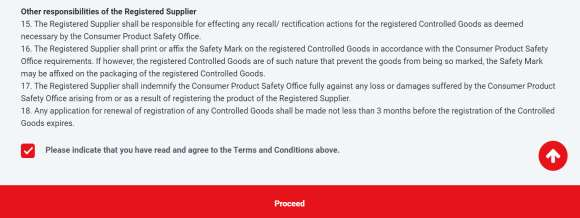

In [ ]:
# ── Unit Test 1: CLIP model loads and vision encoder produces correct dimensions ──
print("=== Test 1: CLIP vision encoder output ===")

sample_b64 = chunks1[0].metadata.get("raw_images", [None])[0]
if sample_b64:
    image_bytes = base64.b64decode(sample_b64)
    pil_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    vector = clip_model.encode(pil_image).tolist()
    print(f"Input type:     PIL Image ({pil_image.width}x{pil_image.height})")
    print(f"Output type:    {type(vector)}")
    print(f"Output length:  {len(vector)} dimensions (expected 512)")
    print(f"Sample values:  {vector[:5]}")
else:
    print("No images found in chunks1[0]")

# ── Unit Test 2: CLIP text encoder also produces 512-dim (cross-modal compatibility) ──
print("=== Test 2: CLIP text encoder output ===")

text_vector = clip_model.encode("dashboard screenshot").tolist()
print(f"Input type:    str")
print(f"Output length: {len(text_vector)} dimensions (expected 512)")
print(f"Same space as vision encoder: {len(text_vector) == len(vector)}")
# Both must be 512 for cross-modal similarity search to work


# ── Unit Test 3: Image vector stores are populated ──
print("=== Test 3: Image vector store counts ===")

print(f"chroma_img_1 entries: {chroma_img_1._collection.count()}")
print(f"chroma_img_2 entries: {chroma_img_2._collection.count()}")

# Inspect one stored entry to confirm metadata is correct
if chroma_img_1._collection.count() > 0:
    sample = chroma_img_1._collection.peek(limit=1)
    print(f"\nSample entry from chroma_img_1:")
    print(f"  id:              {sample['ids'][0]}")
    print(f"  embedding dims:  {len(sample['embeddings'][0])}")
    print(f"  section:         {sample['metadatas'][0].get('section', '')}")
    print(f"  source:          {sample['metadatas'][0].get('source', '')}")
    print(f"  has base64:      {'base64_image' in sample['metadatas'][0]}")
    print(f"  base64 snippet:  {sample['metadatas'][0].get('base64_image', '')[:40]}...")

# ── Unit Test 4: Cross-modal similarity search works ──
print("=== Test 4: Cross-modal retrieval ===")

# Encode a text query through CLIP text encoder
test_query = "dashboard overview"
query_vector = clip_model.encode(test_query).tolist()

if chroma_img_1._collection.count() > 0:
    results = chroma_img_1._collection.query(
        query_embeddings=[query_vector],
        n_results=min(2, chroma_img_1._collection.count()),
        include=["metadatas", "distances"]
    )
    print(f"Query: '{test_query}'")
    print(f"Results returned: {len(results['metadatas'][0])}")
    for i, (meta, dist) in enumerate(zip(results['metadatas'][0], results['distances'][0])):
        print(f"\n  Result {i+1}:")
        print(f"    section:  {meta.get('section', '')}")
        print(f"    source:   {meta.get('source', '')}")
        print(f"    distance: {dist:.4f}  (lower = more similar)")
else:
    print("chroma_img_1 is empty — run build_image_vector_store first")

# ── Unit Test 5: Verify retrieved image is renderable ──
print("=== Test 5: Retrieved image is valid and renderable ===")

if chroma_img_1._collection.count() > 0:
    results = chroma_img_1._collection.query(
        query_embeddings=[query_vector],
        n_results=1,
        include=["metadatas"]
    )
    b64 = results["metadatas"][0][0].get("base64_image", "")
    if b64:
        image_bytes = base64.b64decode(b64)
        pil_image = Image.open(io.BytesIO(image_bytes))
        print(f"Image size:   {pil_image.width}x{pil_image.height}")
        print(f"Image mode:   {pil_image.mode}")
        print(f"Renderable:   True")
        display(pil_image)   # visually confirm the image looks correct
    else:
        print("No base64 found in retrieved metadata")

Printing the heading structure of both PDFs

In [ ]:
collections_to_process = {
    "heading structure 1": {"metadatas": [d.metadata for d in docs1]},
    "heading structure 2": {"metadatas": [d.metadata for d in docs2]}
}
heading_structure = extract_heading_structure(collections_to_process)

for label, structure in heading_structure.items():
    print(f"'{label}':")
    for section, subsections in structure.items():
        print(f"  Section: {section}")
        for sub in subsections:
            print(f"    - Subsection: {sub}")
    print()
print(heading_structure)

# Important: there is no text between the heading '6B. SDoC Registration' and '6B.1.', the '6B.' heading itself doesn't create a standalone chunk

'heading structure 1':
  Section: 1. Preface
  Section: 2. Logging into RS account
  Section: 3. Creating new RS Account
  Section: 4. Dashboard Overview
    - Subsection: 4.1. Controlled Goods Status (CoC)
    - Subsection: 4.2. Controlled Goods Status (SDoC)
    - Subsection: 4.3. Ongoing Allocated Certification Numbers (ACN)
    - Subsection: 4.4. Dashboard: Ongoing drafts
  Section: 5. RS Profile Page Overview
  Section: 6. Overview: “My Controlled Goods” Page
    - Subsection: 6.1. Searching for specific registered CG(s)
    - Subsection: 6.2.  Downloading list of CGs registered by the RS
    - Subsection: 6A.  Viewing detailed information/downloading LOA
    - Subsection: 6B.1. Important Information regarding SDoC submission
    - Subsection: 6B.2. SDoC application process
    - Subsection: 6B.3. Submitting payment for SDoC
    - Subsection: 6B.4. Retrieving Safety Mark number upon successful SDoC application
    - Subsection: 6C. Applying for SDoC renewal
    - Subsection: 6C.1.

### **Memory & States**

#### **Creating `WorkingMemory`**

In [ ]:
@dataclass
class WorkingMemory:
    compiled_query: str = ""
    route: str = ""
    target_doc: str = ""
    relevant_sections: List[str] = field(default_factory=list)
    relevant_subsections: List[str] = field(default_factory=list)
    raw_context: List[str] = field(default_factory=list)
    compiled_context: str = ""
    retrieved_docs: List[Document] = field(default_factory=list)
    retrieved_images: List[dict] = field(default_factory=list)

    def reset(self) -> None:
        self.compiled_query = ""
        self.route = ""
        self.target_doc = ""
        self.relevant_sections = []
        self.relevant_subsections = []
        self.raw_context = []
        self.compiled_context = ""
        self.retrieved_docs = []

#### **Creating `AssistantState`**

In [ ]:
@dataclass
class AssistantState:
    heading_structure: Dict[str, Dict[str, List[str]]]
    chat_history: List[BaseMessage] = field(default_factory=list)
    working_memory: WorkingMemory = field(default_factory=WorkingMemory)

    # Internal mapping to connect Router output to dictionary keys
    _doc_map: Dict[str, str] = field(default_factory=lambda: {
        "PDF_1": "heading structure 1",
        "PDF_2": "heading structure 2"
    })

    def reset(self) -> None:
        self.working_memory.reset()

    @property
    def input_query(self) -> Optional[str]:
        return self.chat_history[-1].content if self.chat_history else None

    @property
    def past_queries(self) -> List[str]:
        return [m.content for m in self.chat_history[:-1] if isinstance(m, HumanMessage)]

    def all_sections(self) -> str:
        """Returns all sections across all documents."""
        sections = []
        for doc_key in self.heading_structure:
            sections.extend(self.heading_structure[doc_key].keys())

        unique_sections = list(dict.fromkeys(sections))
        return json.dumps(unique_sections, indent=4, ensure_ascii=False)

    def all_subsections(self, sections: List[str]) -> str:
        """Returns all subsections for the provided sections across all documents."""
        subsections = []
        for doc_key in self.heading_structure:
            doc_sections = self.heading_structure[doc_key]
            for section in sections:
                if section in doc_sections:
                    subsections.extend(doc_sections[section])

        ordered_subsections = list(dict.fromkeys(subsections))
        return json.dumps(ordered_subsections, indent=4, ensure_ascii=False)

    def allowed_subsections(self, section: str) -> List[str]:
        """Finds subsections for a specific section title by searching all docs."""
        for doc_label in self.heading_structure:
            if section in self.heading_structure[doc_label]:
                return self.heading_structure[doc_label][section]
        return []

    def add_user_query(self, text: str) -> None:
        self.chat_history.append(HumanMessage(content=text))

    def add_ai_response(self, text: str) -> None:
        self.chat_history.append(AIMessage(content=text))

#### **Instantiate the assistant's state**

In [ ]:
# Instantiate state to apply class changes
state = AssistantState(heading_structure=heading_structure)

**Unit test:**

* Inspect `all_sections` in assistant's state

In [ ]:
display(Markdown("### All Sections (Across All Documents)"))
print(state.all_sections())

### All Sections (Across All Documents)

[
    "1. Preface",
    "2. Logging into RS account",
    "3. Creating new RS Account",
    "4. Dashboard Overview",
    "5. RS Profile Page Overview",
    "6. Overview: “My Controlled Goods” Page",
    "7. Application Page Overview",
    "8.  Bills & Payment page",
    "9. Resources page",
    "1.0 Preface",
    "2.0 Introduction",
    "3.0 Key Regulations",
    "4.0 Controlled Goods and their Applicable Safety Standards and Requirements",
    "5.0 Registration",
    "6.0 SAFETY Mark",
    "7.0 Technical File"
]


* Inspect `all_subsections` in assistant's state

In [ ]:
# Retrieve all sections currently in the state
all_sections_list = json.loads(state.all_sections())

display(Markdown("### All Subsections (Across All Documents)"))
print(state.all_subsections(all_sections_list))

### All Subsections (Across All Documents)

[
    "4.1. Controlled Goods Status (CoC)",
    "4.2. Controlled Goods Status (SDoC)",
    "4.3. Ongoing Allocated Certification Numbers (ACN)",
    "4.4. Dashboard: Ongoing drafts",
    "6.1. Searching for specific registered CG(s)",
    "6.2.  Downloading list of CGs registered by the RS",
    "6A.  Viewing detailed information/downloading LOA",
    "6B.1. Important Information regarding SDoC submission",
    "6B.2. SDoC application process",
    "6B.3. Submitting payment for SDoC",
    "6B.4. Retrieving Safety Mark number upon successful SDoC application",
    "6C. Applying for SDoC renewal",
    "6C.1. Payment for SDoC renewal",
    "7.1. Viewing ongoing drafts",
    "7.2. Deleting an unwanted draft",
    "7A. Viewing list of ongoing ACNs from the application page",
    "8.1. Viewing ongoing payments",
    "8.2. Viewing payment history and accessing receipts",
    "4.1 Safety Standards and Requirements of Controlled Goods by Risk Level",
    "4.2 Additional Requirements for registr

### **RAG Workflow**


#### Query Compiler Chain

In [ ]:
str_parser = StrOutputParser()

compiler_system_prompt = """
You are a specialist in the Singapore Consumer Product Safety (CPSR) framework.

Your task is to rewrite the user's query into a standalone retrieval query.

Context:
- CPSA+ Guidebook -> system usage
- CPSR Regulations -> legal requirements

Instructions:
- Rewrite informal, incomplete, or ungrammatical user queries into a clear and formal retrieval query.
- Use past queries only when the current query contains references, omissions, or follow-up phrases
  that cannot be understood on its own (e.g., "that requirement", "the fee", "renewal", "how long").
- If the current query is already complete, do not add unnecessary past context.
- Include domain keywords when relevant (e.g., SDoC, Controlled Goods, CPSA+, CoC, Technical File, LOA).
- If the query is about fees or deadlines, specify the exact context.
- Output ONE clear sentence only.
- Do NOT answer the question; only rewrite it as a retrieval query.

Examples:
User query: hello, I dont know how to use SDOC application?
Rewritten query: What is the SDoC application process in the CPSA+ system?

User query: how to view paymen ah?
Rewritten query: How can I view ongoing payments in the CPSA+ system?

User query: why we need download list of CGs and LOA
Rewritten query: What is the purpose of downloading the list of controlled goods and the LOA in CPSA+?

User query: key regulation of CPSR is what
Rewritten query: What are the key regulations under the Consumer Protection (Safety Requirements) Regulations?

User query: Medium Risk Controlled Goods???
Rewritten query: What are the safety standards and requirements for medium-risk controlled goods?

User query: what about the fee?
Past queries: How to apply for SDoC?
Rewritten query: What is the fee for SDoC application in the CPSA+ system?

User query: how long does it take?
Past queries: Tell me about SDoC renewal
Rewritten query: What is the processing time for SDoC renewal in the CPSA+ system?
"""

query_compiler_prompt = ChatPromptTemplate.from_messages([
    ("system", compiler_system_prompt),
    ("user", """
Query history: {past_queries}

Current query: {input_query}
""")
])

query_compiler_chain = (
    {
        "past_queries": lambda s: " | ".join(s.past_queries),
        "input_query": lambda s: s.input_query
    }
    | query_compiler_prompt
    | model
    | str_parser
)

Unit Testing

In [ ]:
# state.chat_history = [
#     HumanMessage(content="hi, I dont know how to download SDOC application?")
# ]

# state.chat_history = [
#     HumanMessage(content="how to view cert of conformity ah?")
# ]

# state.chat_history = [
#     HumanMessage(content="where apply safety mark and how to prepare")
# ]

# state.chat_history = [
#     HumanMessage(content="key regulation of CPSR is what")
# ]

# state.chat_history = [
#     HumanMessage(content="Registration of CG??")
# ]

state.chat_history = [
    HumanMessage(content="different of CoC, SDOC, ACN")
    ]


# state.chat_history = [
#     HumanMessage(content="Tell me about SDoC renewal"),
#     HumanMessage(content="how long?")
# ]

In [ ]:
output = query_compiler_chain.invoke(state)

print("Output:", output)

Output: What are the differences between the Certificate of Compliance (CoC), the Supplier's Declaration of Conformity (SDoC), and the Approval Certificate Number (ACN) in the context of the CPSR framework?


#### Query Router Chain

In [ ]:
router_system_prompt = """
You are an expert router for Singapore Consumer Product Safety documents.
Your task is to decide which document(s) should be used to answer the retrieval query.

Available documents:

- PDF_1: CPSA+ Guidebook for Registered Suppliers
  Use this for procedural or system-usage questions, such as:
  logging into and create RS account, dashboard usage,
  Controlled Goods Status(CoC)/Controlled Goods Status(SDoC)/Ongoing Allocated Certification Number(ACN),
  application steps, payment steps,
  draft applications, LOA download, and controlled goods list.

- PDF_2: Consumer Protection (Safety Requirements) Regulations
  Use this for legal, regulatory, registration, or technical questions, such as:
  controlled goods definitions, applicable safety standards, risk levels,
  additional requirements for registration of controlled goods,
  parties that need to apply for registration,
  registration of supplier of controlled goods,
  registration of controlled goods,
  Certificate of Conformity (CoC),
  modifications to registered controlled goods,
  Technical File, SAFETY Mark, and exemption-related requirements.

Routing rules:
- Output 'PDF_1' if the query is mainly about system procedures, user actions, navigation, or application steps in CPSA+.
- Output 'PDF_2' if the query is mainly about legal requirements, registration rules, standards, definitions, risk levels, CoC requirements, or regulatory conditions.
- Output 'BOTH' if the query clearly requires both procedural guidance and regulatory information.

- Output 'UNRELATED' if:
  * The query is NOT about Singapore Consumer Product Safety
  * OR it does not relate to CPSA+, controlled goods, CoC, SDoC, SAFETY Mark, or regulations
  * OR it is a general question (e.g., weather, coding, math, personal advice, etc.)
  * OR the intent cannot be answered using the provided documents

Output ONLY one of these exact strings:
PDF_1
PDF_2
BOTH
UNRELATED
"""

query_router_prompt = ChatPromptTemplate.from_messages([
    ("system", router_system_prompt),
    ("user", "{compiled_query}")
])

query_router_chain = (
    {
        "compiled_query": lambda x: x.working_memory.compiled_query
    }
    | query_router_prompt
    | model
    | StrOutputParser()
)

Unit Test

In [ ]:
state.reset()
state.working_memory.compiled_query = "What are the steps to log into CPSA+ using CorpPass?"

route = query_router_chain.invoke(state)
print("Test 1:", route)

Test 1: PDF_1


In [ ]:
state.reset()
state.working_memory.compiled_query = "What are the additional requirements for electrical appliances under CPSR?"

route = query_router_chain.invoke(state)
print("Test 2:", route)

Test 2: PDF_2


In [ ]:
state.reset()
state.working_memory.compiled_query = "How do I ensure my product complies with CPSR and then submit it through CPSA+?"

route = query_router_chain.invoke(state)
print("Test 3:", route)

Test 3: BOTH


In [ ]:
state.reset()
state.working_memory.compiled_query = "What is the capital of Malaysia"

route = query_router_chain.invoke(state)
print("Test 4:", route)

Test 4: UNRELATED


In [ ]:
state.reset()
state.working_memory.compiled_query = "What does CoC stand for?"

route = query_router_chain.invoke(state)
print("Test 5:", route)

Test 5: PDF_2


#### Analyzer Chain 1

In [ ]:
def parse_list_output(text: str):
    text = text.strip()

    # Handle empty response or null indicators
    if not text or text.lower() in ["", "none", '""', "n/a"]:
        return []

    # Split by comma first
    if "," in text:
        items = [item.strip() for item in text.split(",")]
    else:
        # Fallback for newline-separated lists
        items = [line.strip() for line in text.split("\n")]

    # Final cleaning: remove trailing punctuation and surrounding quotes
    clean_items = [
        item.strip().strip('"').strip("'").rstrip(".")
        for item in items if item.strip()
    ]

    return clean_items


list_parser = RunnableLambda(parse_list_output)

def normalize_route(route: str):
    if not route:
        return None
    route = route.upper().replace(" ", "").replace("_", "")

    mapping = {
        "PDF1": "PDF_1",
        "PDF2": "PDF_2",
        "BOTH": "BOTH",
        "UNRELATED": "UNRELATED"
    }
    return mapping.get(route, None)

def get_routed_sections(state):
    route = normalize_route(getattr(state.working_memory, "route", None))
    route_to_doc = {
        "PDF_1": "heading structure 1",
        "PDF_2": "heading structure 2"
    }

    if route == "UNRELATED":
        return []

    if route == "PDF_1":
        return list(state.heading_structure.get(route_to_doc["PDF_1"], {}).keys())

    elif route == "PDF_2":
        return list(state.heading_structure.get(route_to_doc["PDF_2"], {}).keys())

    elif route == "BOTH":
        pdf1 = state.heading_structure.get(route_to_doc["PDF_1"], {})
        pdf2 = state.heading_structure.get(route_to_doc["PDF_2"], {})
        return list(pdf1.keys()) + list(pdf2.keys())

    return []


def format_sections_for_prompt(state):
    sections = get_routed_sections(state)
    if not sections:
        return ""
    return "\n".join(f"- {sec}" for sec in sections)


analyzer_1_system_prompt = """
You are a precision-focused Document Indexing Specialist for the Singapore Consumer Product Safety (CPSR) framework.
Your goal is to map a user's query to specific MAIN SECTION titles from a provided list.

### Selection Instructions:
1. **Keyword Priority**: If the query mentions 'SDoC', 'CoC', 'ACN', 'Safety Mark', or 'Technical File', select every section title containing those terms.
2. **Intent Mapping**:
   - For procedural/system usage (e.g., "how to pay", "where to click"), select sections from Document 1 (Guidebook).
   - For regulatory/legal requirements (e.g., "what is a controlled good", "safety standards"), select sections from Document 2 (Regulations).
3. **High Recall**: If a section is even "plausibly" relevant, include it. It is better to retrieve slightly more context than to miss the answer.
4. **Strict Output**: You must ONLY output the exact strings from the 'Available' list, separated by commas. Do not summarize or add conversational filler.

### Example:
Query: "How do I update my profile and check the status of my SDoC?"
Output: 5. RS Profile Page Overview, 6. Overview: “My Controlled Goods” Page, 6B. SDoC Registration
"""

analyzer_chain_1 = (
    {
        "query": lambda s: s.working_memory.compiled_query,
        "sections": lambda s: format_sections_for_prompt(s),
        "route": lambda s: s.working_memory.target_doc
    }
    | PromptTemplate.from_template(
        f"{analyzer_1_system_prompt}\n\n"
        "User Query: {query}\n"
        "Router Result: {route}\n\n"
        "Available Document Sections:\n{sections}\n\n"
        "Selected Relevant Sections (comma separated):"
    )
    | model
    | StrOutputParser()
    | list_parser
)

Unit Test

In [ ]:
state.working_memory.compiled_query = "What are the steps to log into CPSA+ using CorpPass?"
state.working_memory.route = "PDF_1"

result = analyzer_chain_1.invoke(state)

print("[")
for item in result:
    print(f" '{item}',")
print("]")

[
 '2. Logging into RS account',
]


In [ ]:
state.working_memory.compiled_query = "How do I ensure my product complies with CPSR and then submit it through CPSA+?"
state.working_memory.route = "BOTH"

result = analyzer_chain_1.invoke(state)

print("[")
for item in result:
    print(f" '{item}',")
print("]")

[
 '4.0 Controlled Goods and their Applicable Safety Standards and Requirements',
 '5.0 Registration',
 '6.0 SAFETY Mark',
 '7.0 Technical File',
]


In [ ]:
state.working_memory.compiled_query = "What does CoC stand for?"
state.working_memory.route = "PDF2"

result = analyzer_chain_1.invoke(state)

print("[")
for item in result:
    print(f" '{item}',")
print("]")

[
 '2.0 Introduction',
 '4.0 Controlled Goods and their Applicable Safety Standards and Requirements',
 '6.0 SAFETY Mark',
 '7.0 Technical File',
]


In [ ]:
state.working_memory.compiled_query = "How to bake a chocolate cake"
state.working_memory.route = "UNRELATED"

result_unrelated = analyzer_chain_1.invoke(state)

print("Unrelated output:", result_unrelated)

Unrelated output: ['No relevant sections found']


In [ ]:
state.working_memory.compiled_query = "How do I use CPSA+ from login to managing my Controlled Goods?"
state.working_memory.route = "PDF1"

result = analyzer_chain_1.invoke(state)

print("[")
for item in result:
    print(f" '{item}',")
print("]")

[
 '2. Logging into RS account',
 '4. Dashboard Overview',
 '6. Overview: “My Controlled Goods” Page',
]


#### Analyzer Chain 2

In [ ]:
def get_relevant_subsections(state):
    relevant_sections = getattr(state.working_memory, "relevant_sections", None)

    if not relevant_sections:
        return []

    return state.all_subsections(relevant_sections)

analyzer_2_system_prompt = """
You are a document navigation assistant.

Your task is to select ALL relevant SUBSECTIONS that help answer the user query.

### Instructions:

1. High Recall:
   - Include ALL subsections that are even moderately relevant
   - Prefer including more rather than missing useful content

2. Coverage:
   - If a section is selected, include its important subsections
   - Include both overview (e.g., status, dashboard) AND actions (e.g., apply, submit, renew)

3. Relevance:
   - Include subsections related to:
     - tracking / status
     - searching / viewing
     - application / submission
     - payment / renewal
   - These are all considered part of "managing Controlled Goods"

4. Do NOT include:
   - Completely unrelated sections
   - Duplicates

5. Output format:
   - ONLY comma-separated subsection titles
   - No explanation
"""

analyzer_chain_2 = (
    {
        "query": lambda s: s.working_memory.compiled_query,
        "sections": lambda s: get_relevant_subsections(s)
    }
    | PromptTemplate.from_template(
        f"{analyzer_2_system_prompt}\n\n"
        "User Query: {query}\n\n"
        "Available Subsections:\n{sections}\n\n"
        "Relevant Subselections (comma separated):"
    )
    | model
    | StrOutputParser()
    | list_parser
)

Unit Test

In [ ]:
state.working_memory.compiled_query = "How do I ensure my product complies with CPSR and then submit it through CPSA+?"
state.working_memory.relevant_sections = [
   '3.0 Key Regulations',
   '4.0 Controlled Goods and their Applicable Safety Standards and Requirements',
   '5.0 Registration',
   '7.0 Taechnical File'
]

state.working_memory.route = "PDF_2"

result = analyzer_chain_2.invoke(state)

print("[")
for item in result:
    print(f" '{item}',")
print("]")

[
 '4.1 Safety Standards and Requirements of Controlled Goods by Risk Level',
 '4.2 Additional Requirements for registration of Controlled Goods',
 '5.3 Registration of Controlled Goods',
 '5.4 Certificate of Conformity',
]


In [ ]:
state.working_memory.compiled_query = "How do I ensure my product complies with CPSR and then submit it through CPSA+?"
state.working_memory.relevant_sections = [
    '5. RS Profile Page Overview',
    '6. Overview: “My Controlled Goods” Page',
    '4.0 Controlled Goods and their Applicable Safety Standards and Requirements',
    '6.0 SAFETY Mark',
    '7.0 Technical File'
]
state.working_memory.route = "BOTH"
result = analyzer_chain_2.invoke(state)

print("[")
for item in result:
    print(f" '{item}',")
print("]")

[
 '6.1. Searching for specific registered CG(s)',
 '6A.  Viewing detailed information/downloading LOA',
 '6B.2. SDoC application process',
 '6B.3. Submitting payment for SDoC',
 '6C. Applying for SDoC renewal',
 '6C.1. Payment for SDoC renewal',
 '4.1 Safety Standards and Requirements of Controlled Goods by Risk Level',
 '4.2 Additional Requirements for registration of Controlled Goods',
]


In [ ]:
state.working_memory.compiled_query = "How do I use CPSA+ from login to managing my Controlled Goods?"
state.working_memory.relevant_sections = [
   '2. Logging into RS account',
   '4. Dashboard Overview',
   '6. Overview: “My Controlled Goods” Page'
]

state.working_memory.route = "PDF_1"

result = analyzer_chain_2.invoke(state)

print("[")
for item in result:
    print(f" '{item}',")
print("]")


[
 '4.1. Controlled Goods Status (CoC)',
 '4.2. Controlled Goods Status (SDoC)',
 '4.3. Ongoing Allocated Certification Numbers (ACN)',
 '4.4. Dashboard: Ongoing drafts',
 '6.1. Searching for specific registered CG(s)',
 '6.2.  Downloading list of CGs registered by the RS',
 '6A.  Viewing detailed information/downloading LOA',
 '6B.1. Important Information regarding SDoC submission',
 '6B.2. SDoC application process',
 '6B.3. Submitting payment for SDoC',
 '6B.4. Retrieving Safety Mark number upon successful SDoC application',
 '6C. Applying for SDoC renewal',
 '6C.1. Payment for SDoC renewal',
]


#### Parallel Retriever

In [ ]:
def get_target_doc_labels(state: AssistantState) -> List[str]:
    """
    Return the heading_structure labels that should be searched
    based on routing result.
    """
    route = getattr(state.working_memory, "route", "")

    if route == "PDF_1":
        return ["heading structure 1"]
    elif route == "PDF_2":
        return ["heading structure 2"]
    elif route == "BOTH":
        return ["heading structure 1", "heading structure 2"]
    else:
        return []

def get_vectorstore_by_label(doc_label: str):
    """
    Map heading structure label to the corresponding Chroma vector store.
    """
    mapping = {
        "heading structure 1": chroma_vs_1,
        "heading structure 2": chroma_vs_2
    }
    return mapping.get(doc_label)

def build_section_subsection_pairs(state: AssistantState) -> List[Tuple[str, str, str]]:
    """
    Build valid (doc_label, section, subsection) pairs only for:
    - routed document(s)
    - relevant sections
    - relevant subsections that truly belong to that section
    """
    pairs = []
    target_labels = get_target_doc_labels(state)

    relevant_sections = state.working_memory.relevant_sections or []
    relevant_subsections = state.working_memory.relevant_subsections or []

    if not target_labels or not relevant_sections:
        return pairs

    for doc_label in target_labels:
        doc_structure = state.heading_structure.get(doc_label, {})

        for section in relevant_sections:
            if section not in doc_structure:
                continue

            allowed_subs = doc_structure[section]

            # Case 1: section has real subsections
            if allowed_subs:
                for subsection in relevant_subsections:
                    if subsection in allowed_subs:
                        pairs.append((doc_label, section, subsection))

            # Case 2: section has no subsections, so use subsection='-'
            else:
                # only append once for this section
                pairs.append((doc_label, section, "-"))

    return pairs

def build_dynamic_retrievers(state: AssistantState, k: int = 3) -> Dict[str, Any]:
    """
    Dynamically instantiate one retriever per valid section-subsection pair.
    """
    retrievers = {}
    pairs = build_section_subsection_pairs(state)

    for i, (doc_label, section, subsection) in enumerate(pairs):
        vectorstore = get_vectorstore_by_label(doc_label)
        if vectorstore is None:
            continue

        # Build metadata filter
        metadata_filter = {
            "$and": [
                {"section": section},
                {"subsection": subsection}
            ]
        }

        retriever_name = f"{doc_label}__{section}__{subsection}__{i}"

        retrievers[retriever_name] = vectorstore.as_retriever(
            search_type="similarity",
            search_kwargs={
                "k": k,
                "filter": metadata_filter
            }
        )

    return retrievers

def build_section_level_retrievers(state: AssistantState, k: int = 3) -> Dict[str, Any]:
    """
    Fallback: if no valid section-subsection pair exists,
    build retrievers using section-only filter.
    """
    retrievers = {}
    target_labels = get_target_doc_labels(state)
    relevant_sections = state.working_memory.relevant_sections or []

    idx = 0
    for doc_label in target_labels:
        vectorstore = get_vectorstore_by_label(doc_label)
        doc_structure = state.heading_structure.get(doc_label, {})

        if vectorstore is None:
            continue

        for section in relevant_sections:
            if section not in doc_structure:
                continue

            retriever_name = f"{doc_label}__{section}__section_only__{idx}"
            idx += 1

            retrievers[retriever_name] = vectorstore.as_retriever(
                search_type="similarity",
                search_kwargs={
                    "k": k,
                    "filter": {"section": section}
                }
            )

    return retrievers

def deduplicate_docs(docs: List[Document]) -> List[Document]:
    """
    Remove duplicate documents while preserving order.
    """
    unique_docs = []
    seen = set()

    for doc in docs:
        unique_key = (
            doc.metadata.get("section", ""),
            doc.metadata.get("subsection", ""),
            doc.metadata.get("chunk_id", ""),
            doc.page_content[:120]
        )

        if unique_key not in seen:
            seen.add(unique_key)
            unique_docs.append(doc)

    return unique_docs

def run_parallel_retriever(state: AssistantState, k: int = 3) -> List[str]:
    """
    Build dynamic retrievers based on route + relevant section/subsection pairs,
    run them in parallel, flatten, deduplicate, sort by chunk_id, and return raw text chunks.

    Expected input:
        state: full AssistantState

    Output:
        List[str] -> raw retrieved text chunks
    """
    query = state.working_memory.compiled_query
    if not query:
        state.working_memory.raw_context = []
        state.working_memory.retrieved_docs = []
        return []

    # Step 1: build pair-based retrievers
    retrievers = build_dynamic_retrievers(state, k=k)

    # Step 2: fallback to section-level retrieval if needed
    if not retrievers:
        retrievers = build_section_level_retrievers(state, k=k)

    # Step 3: if still empty, return nothing
    if not retrievers:
        state.working_memory.raw_context = []
        state.working_memory.retrieved_docs = []
        return []

    # Step 4: build chain exactly in teacher-style format
    parallel_retriever_chain = (
        RunnableParallel(retrievers)
        | RunnableLambda(lambda results: [doc for result in results.values() for doc in result])
        | RunnableLambda(deduplicate_docs)
        | RunnableLambda(lambda docs: sorted(docs, key=lambda doc: doc.metadata.get("chunk_id", 10**9)))
    )

    # invoke with compiled query only
    retrieved_docs = parallel_retriever_chain.invoke(query)

    raw_context = []
    for doc in retrieved_docs:
        raw_context.append({
            "text": doc.page_content,
            "images": doc.metadata.get("raw_images", [])
        })

    # update memory
    state.working_memory.retrieved_docs = retrieved_docs
    state.working_memory.raw_context = raw_context

    # image retrieval
    img_store_map = {
        "heading structure 1": chroma_img_1,
        "heading structure 2": chroma_img_2
    }

    retrieved_images = []
    target_labels = get_target_doc_labels(state)
    relevant_sections = state.working_memory.relevant_sections or []

    for doc_label in target_labels:
        img_vs = img_store_map.get(doc_label)
        if img_vs is None or img_vs._collection.count() == 0:
            continue

        # Encode the query text through CLIP text encoder
        # This works because CLIP text and vision embeddings share the same 512-dim space
        # so text query vector can be compared against image vectors directly
        query_vector = clip_model.encode(query).tolist()

        # Query the image collection using the pre-computed query vector
        results = img_vs._collection.query(
            query_embeddings=[query_vector],
            n_results=min(2, img_vs._collection.count()),
            where={"section": {"$in": relevant_sections}} if relevant_sections else None,
            include=["metadatas", "distances"]
        )

        for meta in results["metadatas"][0]:
            b64 = meta.get("base64_image", "")
            if b64:
                retrieved_images.append({
                    "base64":   b64,
                    "section":  meta.get("section", ""),
                    "source":   meta.get("source", "")
                })

    state.working_memory.retrieved_images = retrieved_images

    return raw_context

Unit Testing

In [ ]:
# state.working_memory.compiled_query = "What are the safety standards and requirements for controlled goods by risk level under the Consumer Protection (Safety Requirements) Regulations?"
# state.working_memory.route = "PDF_2"
# state.working_memory.relevant_sections = ["4.0 Controlled Goods and their Applicable Safety Standards and Requirements"]
# state.working_memory.relevant_subsections = ["4.1 Safety Standards and Requirements of Controlled Goods by Risk Level"]

# state.working_memory.raw_context = run_parallel_retriever(state)

# state.working_memory.raw_context

#### Context Compiler Chain

In [ ]:
str_parser = StrOutputParser()

def format_raw_context(state: AssistantState) -> str:
    contexts = state.working_memory.raw_context

    if not contexts:
        return "No retrieved context available."

    formatted = []
    for i, chunk in enumerate(contexts, start=1):
        text = chunk.get("text", "")
        has_image = "Yes" if chunk.get("images") else "No"

        formatted.append(
            f"[Context {i}]\n{text}\n[Has Image: {has_image}]"
        )

    return "\n\n".join(formatted)


context_compiler_prompt = PromptTemplate.from_template(
    """
You are a Context Compiler for a retrieval-based assistant on Singapore Consumer Product Safety documents.

Your task is to filter, compress, and organize the retrieved context into a clean, high-signal evidence summary.

Instructions:
- Use ONLY the retrieved contexts provided.
- Keep only information directly relevant to the query.
- Remove repetition, overlap, irrelevant details, and noise.
- Preserve important procedural, regulatory, and technical details.
- Do NOT answer the user directly.
- Do NOT add outside knowledge.
- If the context is insufficient, state that clearly.

Output format:
To (based on question), you can:-
- Key point 1:
  ... \n
- Key point 2:
  ... \n
- Key point 3:
  ... \n

The Key point should paraphase based on related content and bold it.

Query:
{query}

Retrieved Contexts:
{contexts}
"""
)

context_compiler_chain = (
    {
        "query": lambda s: s.working_memory.compiled_query,
        "contexts": lambda s: format_raw_context(s)
    }
    | context_compiler_prompt
    | model
    | str_parser
)

def run_context_compiler(state: AssistantState) -> AssistantState:
    compiled = context_compiler_chain.invoke(state)
    state.working_memory.compiled_context = compiled
    return state

Unit Testing

In [ ]:
with get_openai_callback() as cb:
    state.working_memory.compiled_context = context_compiler_chain.invoke(state)

display(Markdown(state.working_memory.compiled_context))

To your query about using CPSA+ for managing Controlled Goods, you can: 

- **Access CPSA+ by logging in with your credentials to begin managing your Controlled Goods.** 

- **Utilize the dashboard to navigate through various functionalities related to Controlled Goods management.** 

- **Follow the provided guidelines within CPSA+ for compliance and reporting requirements specific to Controlled Goods.** 

(Note: The context provided is insufficient for detailed procedural steps.)

#### Responder Chain

In [ ]:
from langchain_core.runnables import RunnableLambda
from langchain_core.messages import AIMessage

def _multimodal_responder_fn(state: AssistantState) -> AIMessage:
    client = OpenAI()
    images  = state.working_memory.retrieved_images or []
    context = state.working_memory.compiled_context or "No context available."
    query   = state.chat_history[-1].content if state.chat_history else ""

    messages = [{
        "role": "system",
        "content": """
You are a retrieval-based assistant for Singapore Consumer Product Safety documents.
Answer ONLY from the provided context and images. Do not use outside knowledge.
If an image is provided, describe what you see and incorporate it into your answer.
"""
    }]

    for msg in state.chat_history[:-1]:
        if isinstance(msg, HumanMessage):
            messages.append({"role": "user",      "content": msg.content})
        elif isinstance(msg, AIMessage):
            messages.append({"role": "assistant", "content": msg.content})

    if images:
        content = [
            {"type": "text", "text": f"Retrieved Context:\n{context}"},
            {"type": "text", "text": f"\n{len(images)} relevant image(s) retrieved:"}
        ]
        for i, img in enumerate(images):
            content.append({
                "type": "text",
                "text": f"\n[Image {i+1} | Section: '{img['section']}' | Source: {img['source']}]"
            })
            content.append({
                "type": "image_url",
                "image_url": {
                    "url":    f"data:image/jpeg;base64,{img['base64']}",
                    "detail": "high"
                }
            })
        content.append({"type": "text", "text": f"\nUser Question: {query}"})
        messages.append({"role": "user", "content": content})
    else:
        messages.append({
            "role": "user",
            "content": f"Retrieved Context:\n{context}\n\nUser Question: {query}"
        })

    resp = client.chat.completions.create(
        model="gpt-5.4",
        messages=messages,
        max_completion_tokens=1000,
        temperature=0.0
    )
    return AIMessage(content=resp.choices[0].message.content)

responder_chain = RunnableLambda(_multimodal_responder_fn)

Unit Testing

In [ ]:
state.chat_history = []
state.add_user_query("What are the safety standards and requirements for controlled goods by risk level under the Consumer Protection (Safety Requirements) Regulations?")
with get_openai_callback() as cb:
    output = responder_chain.invoke(state)

display(Markdown(output.content))

The provided context does not contain the safety standards or the requirements for controlled goods by risk level under the Consumer Protection (Safety Requirements) Regulations.

What the context does say is only that CPSA+ can be used to manage Controlled Goods, including:
- logging in to access CPSA+,
- using the dashboard for Controlled Goods management,
- following guidelines within CPSA+ for compliance and reporting.

No sections, subsections, risk levels, or safety standards are provided in the retrieved context, so I cannot answer your specific question from the supplied material.

### **In-notebook Chat Interface (For Demo)**

In [ ]:
class Assistant(Runnable):
    def __init__(self, model, state: AssistantState):
        super().__init__()
        self.model = model
        self.state = state

        # use existing chains you already built
        self.query_compiler_chain = query_compiler_chain
        self.query_router_chain = query_router_chain
        self.analyzer_chain_1 = analyzer_chain_1
        self.analyzer_chain_2 = analyzer_chain_2
        self.context_compiler_chain = context_compiler_chain
        self.responder_chain = responder_chain

    def stream(self, input: str, config: Optional[dict] = None) -> Iterator[Any]:
        """
        Primary stream-first interface.
        Runs the full linear workflow and streams final response chunks.
        """

        # Step 1: reset working memory only
        self.state.reset()

        # Step 2: add current user query to chat history
        self.state.add_user_query(input)

        # Step 3: compile query
        yield "\n\n<sub>⚙️ Compiling query...</sub>\n\n"
        self.state.working_memory.compiled_query = self.query_compiler_chain.invoke(self.state)

        # Step 4: route query
        yield "\n\n<sub>⚙️ Routing query to the correct document...</sub>\n\n"
        self.state.working_memory.route = self.query_router_chain.invoke(self.state).strip()

        # Step 5: handle unrelated
        if self.state.working_memory.route == "UNRELATED":
            self.state.working_memory.relevant_sections = []
            self.state.working_memory.relevant_subsections = []
            self.state.working_memory.raw_context = []
            self.state.working_memory.compiled_context = (
                "The question is unrelated to the provided Singapore Consumer Product Safety documents."
            )

        else:
            # Step 6: analyze relevant sections
            yield "\n\n<sub>⚙️ Identifying relevant main sections...</sub>\n\n"
            self.state.working_memory.relevant_sections = self.analyzer_chain_1.invoke(self.state)

            # normalize empty outputs
            if not self.state.working_memory.relevant_sections or self.state.working_memory.relevant_sections == []:
                self.state.working_memory.relevant_sections = []

            if self.state.working_memory.relevant_sections:
                # Step 7: analyze relevant subsections
                yield "\n\n<sub>⚙️ Identifying relevant subsections...</sub>\n\n"
                self.state.working_memory.relevant_subsections = self.analyzer_chain_2.invoke(self.state)

                if not self.state.working_memory.relevant_subsections or self.state.working_memory.relevant_subsections == []:
                    self.state.working_memory.relevant_subsections = []

                # Step 8: retrieve raw context
                yield "\n\n<sub>⚙️ Retrieving relevant chunks...</sub>\n\n"
                self.state.working_memory.raw_context = run_parallel_retriever(self.state)

                # Step 9: compile context
                yield "\n\n<sub>💬 Finalizing retrieved evidence...</sub>\n\n"
                self.state.working_memory.compiled_context = self.context_compiler_chain.invoke(self.state)

            else:
                # no section found
                self.state.working_memory.relevant_subsections = []
                self.state.working_memory.raw_context = []
                self.state.working_memory.compiled_context = (
                    "No relevant information was found in the provided documents."
                )

        # Step 10: stream final response
        yield "<br>"

        n_imgs = len(self.state.working_memory.retrieved_images or [])
        if n_imgs:
            yield f"\n\n<sub>🖼️ Reasoning over {n_imgs} image(s)...</sub>\n\n"

        result = self.responder_chain.invoke(self.state)
        final_text = result.content if hasattr(result, "content") else str(result)

        for char in final_text:
            yield char

        # Step 11: save final response into chat history
        if final_text.strip():
            self.state.add_ai_response(final_text.strip())

    def invoke(self, input: str, config: Optional[dict] = None, **kwargs: Any) -> AIMessage:
        """
        Secondary non-streaming entrypoint required by Runnable.
        Consumes stream fully and returns the final AIMessage.
        """
        for _ in self.stream(input, config=config):
            pass

        # return final AI message from chat history
        if self.state.chat_history and isinstance(self.state.chat_history[-1], AIMessage):
            return self.state.chat_history[-1]

        return AIMessage(content="")

In [ ]:
assistant = Assistant(model=model, state=state)

In [ ]:
assistant = Assistant(model=model, state=state)

def stream_markdown(chunks, handle, buffer):
    buffer += "**🤖 CPS Assistant**: "

    for c in chunks:
        buffer += c.content if hasattr(c, "content") else str(c)
        handle.update(Markdown(buffer))

    buffer += "\n\n"
    return handle, buffer


buffer = "**🤖 CPS Assistant**: Hi! I am a Singapore Consumer Product Safety Assistant. I can help you with CPSA+ procedures and CPSR regulations.\n\n<br>"
handle = display(Markdown(buffer), display_id=True)

text = widgets.Text(
    placeholder="Type your message and press Enter",
    layout=widgets.Layout(width="80%")
)
send = widgets.Button(description="Send")
ui = widgets.HBox([text, send])
display(ui)

def handle_chat_turn(_=None):
    global buffer, handle

    query = text.value.strip()
    if not query:
        return

    text.value = ""

    buffer += f"**👤 User**: {query}\n\n<br>"
    handle.update(Markdown(buffer))

    with get_openai_callback() as cb:
        handle, buffer = stream_markdown(assistant.stream(query), handle, buffer)

    buffer += (
        f"<sub>tokens: prompt={cb.prompt_tokens}, completion={cb.completion_tokens}, "
        f"total={cb.total_tokens}"
        + (f", cost=${cb.total_cost:.6f}" if getattr(cb, 'total_cost', None) is not None else "")
        + "</sub>\n\n<br>"
    )
    handle.update(Markdown(buffer))

# Clear previous chat history to start a fresh conversation
state.chat_history = []
send.on_click(handle_chat_turn)
text.on_submit(handle_chat_turn)

**🤖 CPS Assistant**: Hi! I am a Singapore Consumer Product Safety Assistant. I can help you with CPSA+ procedures and CPSR regulations.

<br>**👤 User**: my name is steven

<br>**🤖 CPS Assistant**: 

<sub>⚙️ Compiling query...</sub>



<sub>⚙️ Routing query to the correct document...</sub>

<br>I can only answer using the provided Singapore Consumer Product Safety context.

Your message says: “my name is steven.”  
So based on that, your name is Steven.

<sub>tokens: prompt=894, completion=8, total=902, cost=$0.000139</sub>

<br>**👤 User**: what is my name

<br>**🤖 CPS Assistant**: 

<sub>⚙️ Compiling query...</sub>



<sub>⚙️ Routing query to the correct document...</sub>

<br>Your name is Steven.

<sub>tokens: prompt=909, completion=19, total=928, cost=$0.000148</sub>

<br>**👤 User**: what is utar?

<br>**🤖 CPS Assistant**: 

<sub>⚙️ Compiling query...</sub>



<sub>⚙️ Routing query to the correct document...</sub>

<br>The provided context says the question is unrelated to the Singapore Consumer Product Safety documents, so I can’t answer it from the given materials.

<sub>tokens: prompt=913, completion=18, total=931, cost=$0.000148</sub>

<br>

In [ ]:
for message in state.chat_history:
    print(message)

content='What is my name?' additional_kwargs={} response_metadata={}
content='I can’t determine your personal name from the provided context.\n\nWhat the context says is:\n- Log into your existing Registered Supplier account using CorpPass.\n- Use “edit profile” to view or update company details, including contact persons.\n- Use “Retrieve Company Info” to refresh company information based on UEN.\n\nSo, to find your name in CPSA+, you would need to log in to your RS account and check your profile or contact person details.' additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
content='My name is Steven.' additional_kwargs={} response_metadata={}
content='Steven.' additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
content='What is my name' additional_kwargs={} response_metadata={}
content='I can’t determine your name from the provided context.' additional_kwargs={} response_metadata={} tool_calls=[] invalid_tool_calls=[]
